# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**



### Grupo 3:

BAGGINI, Mariano

DA SILVA, Rocio

GRUZYCKI, Sergio

NEDEL, Agustina

# **Práctico Entregable Aprendizaje No Supervisado 2026**


Utilizar la base de jugadores “male_players.csv” disponible en la página de Kaggle https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset?select=male_players.csv.

### **1. Análisis exploratorio inicial de la base.**

 Se espera que el análisis incluya, como mínimo:

1.1. Dimensiones de la base (cantidad de filas y columnas) y tipos de variables presentes (numéricas, categóricas, identificadores, etc.).

1.2. Identificación de las columnas relevantes para el objetivo del trabajo (encontrar grupos de jugadores con habilidades equivalentes), descartando desde el inicio aquellas que claramente no aportan (identificadores, URLs de imágenes, etc.). Justificación explícita de qué variables se conservan y cuáles se descartan para las etapas siguientes del trabajo, explicando el criterio utilizado (relevancia para el objetivo, redundancia con otras variables, calidad de los datos, etc.).

1.3. Detección y tratamiento de valores faltantes (¿qué variables tienen missing values, en qué proporción, y qué se decidió hacer: imputar, descartar filas/columnas, etc.?) y de posibles duplicados.

1.4. Estadística descriptiva de las variables numéricas relevantes (medidas de tendencia central y dispersión), señalando casos llamativos (rangos inesperados, asimetrías fuertes, outliers evidentes).

1.5. Distribución de las principales variables categóricas: posición, liga y nacionalidad, entre otras que el grupo considere relevantes, con al menos una visualización por variable.

### **2. Evaluación visual e intuitiva de dos a dos variables numéricas por vez.**

Sugerencia: hagan los scatterplots de las combinaciones de dos variables que tengan algún sentido para ustedes, porque todas las combinaciones de variables son muchas y no van a poder analizarlas como merecen.

### **3. Pregunta: ¿Se realizó alguna normalización o escalado de la base? ¿Por qué?**

### **4. Aplicación de clustering para encontrar grupos de jugadores con habilidades equivalentes.**

Por ejemplo, jugadores que podrían intercambiarse en el caso de una lesión o cuando un jugador está cansado. Para esto utilice como mínimo dos técnicas de clustering: por ejemplo k-medias,MinShift, DBSCAN, mezcla de Gaussianas y/o Single linkage y otras jerárquicas. Justifiquen por qué eligen los diferentes hiper-parámetros que se puedan elegir según el método: número de clusters, medida de distancia, criterio de aglomeración… Utilicen al menos una métrica cuantitativa de evaluación de clustering (por ejemplo, coeficiente de silhouette, índice de rand ajustado, u otra que consideren pertinente) para comparar los resultados obtenidos con las distintas técnicas y/o configuraciones de hiperparámetros probadas, y justifiquen a partir de esas métricas cuál configuración/método les resultó más adecuado.

### **5. Análisis cualitativo de los clusters encontrados.**

¿Qué hay en cada cluster? ¿Son efectivamente equivalentes los jugadores de un cluster, es decir, podrían cumplir el mismo rol en un equipo? Si se trata de clusters heterogéneos, ¿por qué razón pueden haber sido agrupadas las jugadoras del cluster? ¿Qué motiva las diferencias en tamaño?

### **6. Uso de alguna transformación (proyección, Embedding) para visualizar los resultados y/o usarla como preprocesado para aplicar alguna técnica de clustering.**

### **7. Comparación de interpretaciones humano vs. LLMs sobre el análisis de clusters.**
Para reflexionar críticamente sobre el rol del conocimiento experto/de dominio frente a la interpretación automática de resultados de clustering, y sobre las capacidades y limitaciones actuales de los modelos de lenguaje para el análisis de datos.

7.1. Tomar los resultados del punto 5 (caracterización de clusters ya realizada por el grupo) y presentarle a Claude, ChatGPT y Gemini exactamente la misma información: por ejemplo, tabla de centroides/estadísticos descriptivos por cluster, tamaño de cada cluster, y las variables utilizadas para clusterizar (sin incluir la interpretación propia del grupo, para no sesgar al modelo).

7.2. Pedirle a cada uno de los tres modelos, con el mismo prompt, que interprete los clusters: qué representa cada uno, si los jugadores dentro de un cluster son "equivalentes", y qué podría explicar la heterogeneidad o el tamaño de los grupos.

7.3. Documentar textualmente (o via capturas) las tres respuestas obtenidas.

7.4. Realizar un análisis comparativo entre las tres respuestas y la interpretación propia del grupo (la del punto 5), atendiendo especialmente a:

Coincidencias y diferencias entre los tres modelos.

Casos en que algún modelo haya "alucinado" datos, sacado conclusiones no sustentadas por los números, o generalizado de forma poco rigurosa.

Casos en que el grupo, gracias a conocimiento de dominio (reglas del fútbol, entendimiento de posiciones, lógica de mercado de pases, conocimiento de jugadores reales, contexto de la temporada/base de datos, etc.), pudo identificar matices, errores o explicaciones que ningún modelo mencionó.

Información contextual que un experto humano valora naturalmente pero que los modelos no tienen forma de inferir sólo de números (ej.: un jugador lesionado en el momento del snapshot de datos, un jugador joven con potencial subestimado por las métricas actuales, diferencias entre ligas de distinto nivel competitivo que igualan estadísticas de forma engañosa, etc.).

Diferencias en el "tono" de certeza: ¿los modelos matizan sus afirmaciones o presentan interpretaciones especulativas como si fueran hechos?

7.5. Conclusión breve reflexionando sobre: ¿en qué tareas de este análisis un LLM aporta valor real (por ejemplo, generación rápida de hipótesis, redacción, resumen)? ¿En qué tareas resulta insuficiente o directamente engañoso sin supervisión experta? ¿Qué rol debería tener, en la práctica profesional de un/a científico/a de datos, el uso de estas herramientas para interpretar resultados de un análisis no supervisado?

## **1. Análisis exploratorio inicial de la base.**

### **1.1. Dimensiones de la base  y tipos de variables presentes (numéricas, categóricas, identificadores, etc.).**

In [1]:
# Librerías
import os, sys, itertools, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', None)
sns.set_context('talk')

In [2]:
# Carga del dataset
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("stefanoleone992/ea-sports-fc-24-complete-player-dataset")
print(path)
!ls "{path}"

100%|██████████| 28.0M/28.0M [00:00<00:00, 35.0MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/versions/4
female_coaches.csv  female_teams.csv  male_players.csv
female_players.csv  male_coaches.csv  male_teams.csv


In [3]:
# Vista previa
df = pd.read_csv(f"{path}/male_players.csv", low_memory=False)
data_raw = df.copy()
df.head()


,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_id,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,181500000.0,230000.0,24,1998-12-20,182,75,73.0,Paris Saint Germain,16.0,Ligue 1,1.0,LW,7.0,NaN,2018-07-01,2024.0,18,France,1335.0,LW,10.0,Right,4,5,5,High/Low,Unique,Yes,349400000.0,"#Speedster, #Dribbler, #Acrobat, #Clinical finisher, #Complete forward","Quick Step +, Rapid, Flair, Trivela",97.0,90.0,80.0,92.0,36.0,78.0,78,94,73,86,84,93,80,69,71,92,97,97,93,93,82,90,88,88,77,83,64,38,93,83,84,88.0,26,34,32,13,5,7,11,6,NaN,90+3,90+3,90+3,91,91,91,91,91,89+3,89+3,89+3,89+3,81+3,81+3,81+3,89+3,68+3,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,185000000.0,340000.0,22,2000-07-21,195,94,10.0,Manchester City,13.0,Premier League,1.0,ST,9.0,NaN,2022-07-01,2027.0,36,Norway,1352.0,ST,9.0,Left,3,3,5,High/Medium,Unique,Yes,356100000.0,"#Aerial threat, #Distance shooter, #Strength, #Clinical finisher, #Complete forward","Acrobatic +, Power Header, Quick Step",89.0,93.0,66.0,80.0,45.0,88.0,47,96,83,77,90,79,77,62,53,82,82,94,76,94,72,94,93,76,93,86,87,43,96,74,84,87.0,38,47,29,7,14,13,11,7,NaN,90+3,90+3,90+3,82,86,86,86,82,82+3,82+3,82+3,79+3,74+3,74+3,74+3,79+3,62+3,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,1991-06-28,181,75,10.0,Manchester City,13.0,Premier League,1.0,SUB,17.0,NaN,2015-08-30,2025.0,7,Belgium,1325.0,CAM,7.0,Right,5,4,5,High/Medium,Unique,Yes,190600000.0,"#Dribbler, #Playmaker, #Distance shooter, #Crosser, #Complete midfielder","Pinged Pass +, Dead Ball, Incisive Pass, Long Ball Pass, Whipped Cross, Trivela",72.0,88.0,94.0,87.0,65.0,78.0,95,85,55,94,83,86,92,83,94,92,72,72,74,92,78,92,72,88,74,92,75,66,88,95,83,88.0,66,70,53,15,13,5,10,13,NaN,83+3,83+3,83+3,87,88,88,88,87,89+2,89+2,89+2,88+3,90+1,90+1,90+1,88+3,79+3,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,41000000.0,23000.0,36,1987-06-24,169,67,112893.0,Inter Miami,39.0,Major League Soccer,1.0,RF,10.0,NaN,2023-07-16,2025.0,52,Argentina,1369.0,RW,10.0,Left,4,4,5,Low/Low,Unique,Yes,61500000.0,"#Dribbler, #Playmaker, #FK Specialist, #Acrobat, #Clinical finisher, #Complete midfielder, #Complete forward","Technical +, Finesse Shot, Dead Ball, Pinged Pass, Tiki Taka, Quick Step, Trivela",80.0,87.0,90.0,94.0,33.0,64.0,83,89,60,91,86,96,93,93,90,

In [4]:
# Dimensiones básicas - Cantidad de filas y columnas
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

Cantidad de filas: 180021
Cantidad de columnas: 109


### Diccionario de variables inicial

| Variable | Descripción | Tipo |
| --- | --- | --- |
| `player_id` | player id on sofifa | id |
| `player_url`| url of the scraped player | url |
| `fifa_version` | fifa version of team's data (from 15 to 24) | id |
| `fifa_update` | fifa update number of team's data | id |
| `update_as_of` | fifa date of update of team's data | fecha |
| `short_name` | player short name | texto |
| `long_name` | player long name | texto |
| `player_positions` | player preferred positions | categórica |
| `overall` | player current overall attribute | num |
| `potential` | player potential overall attribute | num |
| `value_eur` | player value (in eur) | num |
| `wage_eur` | player weekly wage (in eur) | num |
| `age` | player age | num |
| `dob` | player date of birth | fecha |
| `height_cm` | player height (in cm) | num |
| `weight_kg` | player weight (in kg) | num |
| `club_team_id` | club team_id where the player plays | id |
| `club_name` | club name where the player plays | categórica |
| `league_id` | league id where the team played in that fifa version | id |
| `league_name` | league name where the player played | categórica |
| `league_level` | level of the league where the player played | num |
| `club_position` | player position in the club (sub, res, etc.) | categórica |
| `club_jersey_number` | player jersey number in the club | num |
| `club_loaned_from` | club loaning out the player - if applicable | categórica |
| `club_joined_date` | date when the player joined his current club | fecha |
| `club_contract_valid_until_year` | player contract expiration date | num |
| `nationality_id` | player nationality id | id |
| `nationality_name` | player nationality name | categórica |
| `nation_team_id` | national team_id where the player plays | id |
| `nation_position` | player position in the national team | categórica |
| `nation_jersey_number` | player jersey number in the national team | num |
| `preferred_foot` | player preferred foot | categórica |
| `weak_foot` | player weak foot attribute | num |
| `skill_moves` | player skill moves attribute | num |
| `international_reputation` | player international reputation attribute | num |
| `work_rate` | player work rate attributes (attacking / defensive) | categórica |
| `body_type` | player body type | categórica |
| `real_face` | player real face | booleana |
| `release_clause_eur` | player release clause (in eur) - if applicable | num |
| `player_tags` | player tags | texto |
| `player_traits` | player traits | texto |
| `pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic` | atributos resumen de campo | num |
| `attacking_*` (crossing, finishing, heading_accuracy, short_passing, volleys) | atributos de ataque | num |
| `skill_*` (dribbling, curve, fk_accuracy, long_passing, ball_control) | atributos técnicos | num |
| `movement_*` (acceleration, sprint_speed, agility, reactions, balance) | atributos de movimiento | num |
| `power_*` (shot_power, jumping, stamina, strength, long_shots) | atributos físicos | num |
| `mentality_*` (aggression, interceptions, positioning, vision, penalties, composure) | atributos mentales | num |
| `defending_*` (marking_awareness, standing_tackle, sliding_tackle) | atributos defensivos | num |
| `goalkeeping_*` (diving, handling, kicking, positioning, reflexes, speed) | atributos de arquero | num |
| `ls`,`st`,`rs`,`lw`,`lf`,`cf`,`rf`,`rw`,`lam`,`cam`,`ram`,`lm`,`lcm`,`cm`,`rcm`,`rm`,`lwb`,`ldm`,`cdm`,`rdm`,`rwb`,`lb`,`lcb`,`cb`,`rcb`,`rb`,`gk` | rating del jugador jugando en cada posición (derivado, formato object) | derivada |

In [5]:
# Tipos de datos
resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'No Nulos': df.notna().sum(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique(),
    'Ejemplo': df.iloc[0],
})
display(resumen.sort_values(by='% Nulos', ascending=False))

,Tipo,No Nulos,Nulos,% Nulos,Únicos,Ejemplo
nation_team_id,float64,10098,169923,94.39,56,1335.0
nation_position,object,10098,169923,94.39,29,LW
nation_jersey_number,float64,10098,169923,94.39,34,10.0
club_loaned_from,object,10723,169298,94.04,831,NaN
player_tags,object,13918,166103,92.27,204,"#Speedster, #Dribbler, #Acrobat, #Clinical finisher, #Complete forward"
goalkeeping_speed,float64,20024,159997,88.88,57,NaN
player_traits,object,81805,98216,54.56,5208,"Quick Step +, Rapid, Flair, Trivela"
release_clause_eur,float64,120722,59299,32.94,1919,349400000.0
mentality_composure,float64,147133,32888,18.27,88,88.0
shooting,float64,159997,20024,11.12,81,90.0


La base tiene 180.021 filas y 109 columnas.

Se encontraron identificadores (`player_id`, `player_url`), variables numéricas continuas/discretas de habilidad y desempeño, variables categóricas (posición, equipo, nacionalidad, pie hábil, etc) variables de texto libre (`player_traits`, `player_tags`) fechas (`dob`, `club_joined_date`) y columnas de rating de posición que quedan en formato object.

Como complemento al diccionario de variables, se agrupan las 109 columnas por familia (prefijo del nombre), para tener una visión estructural de qué tipo de información predomina en el dataset antes de decidir qué se conserva y qué se descarta.

In [6]:
# Exploración de columnas por familia
cols = df.columns.tolist()
familias = ['attacking_', 'skill_', 'movement_', 'power_', 'mentality_',
            'defending_', 'goalkeeping_', 'club_', 'nation_', 'league_']

for fam in familias:
    matched = [c for c in cols if c.startswith(fam)]
    print(f"{fam:15s} ({len(matched)}): {matched}")

print("\nSin prefijo reconocido:")
resto = [c for c in cols if not any(c.startswith(f) for f in familias)]
print(resto)

attacking_      (5): ['attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys']
skill_          (6): ['skill_moves', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control']
movement_       (5): ['movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance']
power_          (5): ['power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots']
mentality_      (6): ['mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure']
defending_      (3): ['defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle']
goalkeeping_    (6): ['goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed']
club_           (7): ['club_team_i

### **1.1.b. Variación de características entre versiones**

Se evalúa cómo varía la disponibilidad de las columnas de habilidad a lo largo de las 10 versiones, para verificar si trabajar solo con la más reciente (FC24) es representativo o si se pierde información relevante.

Para explorar la cantidad de versiones del dataset y medir la disponibilidad de las columnas de habilidad a través de las versiones, se define `habilidades_check`, que incluye las variables resumen, con el objetivo de detectar si alguna de estas columnas tiene problemas de disponibilidad entre versiones, antes que decidir que se descarta. La lista final y curada para el clustering se define más adelante.  

Este análisis se realiza sobre el dataset completo, con las 10 versiones apiladas antes de seleccionar columnas o definir grupos, ya que una vez filtrada la base no queda variación entre versiones para comparar.

In [7]:
habilidades_check = ['overall', 'potential', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'attacking_crossing','attacking_finishing',
    'attacking_heading_accuracy','attacking_short_passing','attacking_volleys','skill_dribbling', 'skill_curve',
    'skill_fk_accuracy','skill_long_passing','skill_ball_control','movement_acceleration','movement_sprint_speed',
    'movement_agility','movement_reactions','movement_balance','power_shot_power','power_jumping','power_stamina',
    'power_strength','power_long_shots','mentality_aggression','mentality_interceptions','mentality_positioning',
    'mentality_vision','mentality_penalties','mentality_composure','defending_marking_awareness','defending_standing_tackle',
    'defending_sliding_tackle','goalkeeping_handling','goalkeeping_diving','goalkeeping_kicking','goalkeeping_positioning',
    'goalkeeping_reflexes','goalkeeping_speed']

In [8]:
# Cantidad de versiones
print("Cantidad de jugadores únicos (player_id):", df['player_id'].nunique())
versiones = sorted(int(v) for v in df['fifa_version'].unique())
print(versiones)

Cantidad de jugadores únicos (player_id): 53111
[15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [9]:
# ¿Cuántas veces aparece cada jugador en todas las versiones?
apariciones_por_jugador = df.groupby('player_id').size()
apariciones_por_jugador.describe()

,0
count,53111.000000
mean,3.389524
std,2.644226
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,10.000000


In [10]:
#¿Un mismo jugador puede tener más de una fila o de un fifa_update por versión?
duplicados_dentro_version = df.groupby(['player_id','fifa_version']).size()
print("Máximo de filas para un mismo jugador en la misma versión:", duplicados_dentro_version.max())
print("Cantidad de casos con más de 1 fila en la misma versión:", (duplicados_dentro_version>1).sum())

Máximo de filas para un mismo jugador en la misma versión: 1
Cantidad de casos con más de 1 fila en la misma versión: 0


El dataset combina múltiples versiones de FIFA/FC por jugador. Hay 53.111 jugadores únicos, cada uno apareciendo en promedio 3.4 versiones, sin duplicados dentro de una misma versión.


In [11]:
# % de nulos por columna de habilidad
faltantes_por_version = (
    df
    .groupby('fifa_version')[habilidades_check]
    .apply(lambda g: g.isnull().mean() * 100)
    .round(2)
)
faltantes_por_version

,overall,potential,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_handling,goalkeeping_diving,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
fifa_version,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
15.0,0.0,0.0,10.99,10.99,10.99,10.99,10.99,10.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.01
16.0,0.0,0.0,10.92,10.92,10.92,10.92,10.92,10.92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.08
17.0,0.0,0.0,11.33,11.33,11.33,11.33,11.33,11.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.67
18.0,0.0,0.0,11.25,11.25,11.25,11.25,11.25,11.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.75
19.0,0.0,0.0,11.22,11.22,11.22,11.22,11.22,11.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.78
20.0,0.0,0.0,11.15,11.15,11.15,11.15,11.15,11.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.85
21.0,0.0,0.0,10.99,10.99,10.99,10.99,10.99,10.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.01
22.0,0.0,0.0,11.08,11.08,11.08,11.08,11.08,11.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.92
23.0,0.0,0.0,11.15,11.15,11.15,11.15,11.15,11.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.85


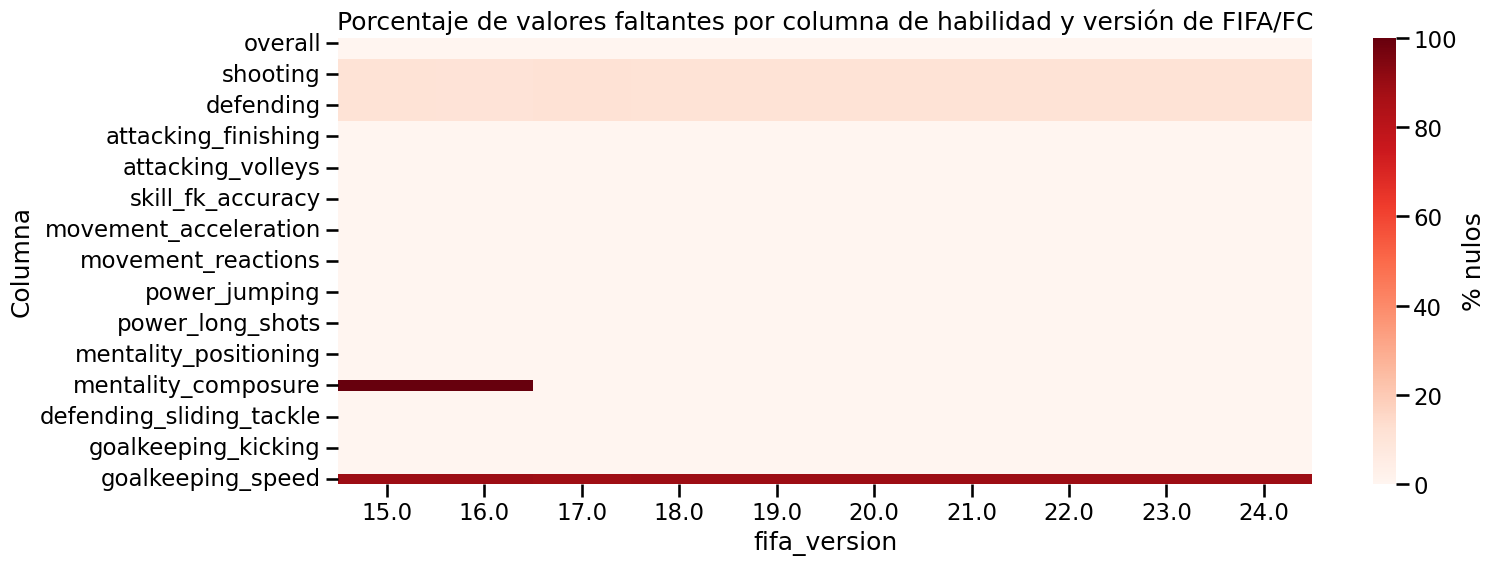

In [12]:
# Heatmap dónde se concentran los nulos
plt.figure(figsize=(16, 6))
sns.heatmap(faltantes_por_version.T, cmap='Reds', cbar_kws={'label': '% nulos'})
plt.title('Porcentaje de valores faltantes por columna de habilidad y versión de FIFA/FC')
plt.xlabel('fifa_version')
plt.ylabel('Columna')
plt.tight_layout()
plt.show()

In [13]:
# Cantidad de features utilizables
umbral = 50
features_utilizables_por_version = (faltantes_por_version < umbral).sum(axis=1)
features_utilizables_por_version.name = 'n_features_utilizables'
features_utilizables_por_version

,n_features_utilizables
fifa_version,
15.0,41
16.0,41
17.0,42
18.0,42
19.0,42
20.0,42
21.0,42
22.0,42
23.0,42


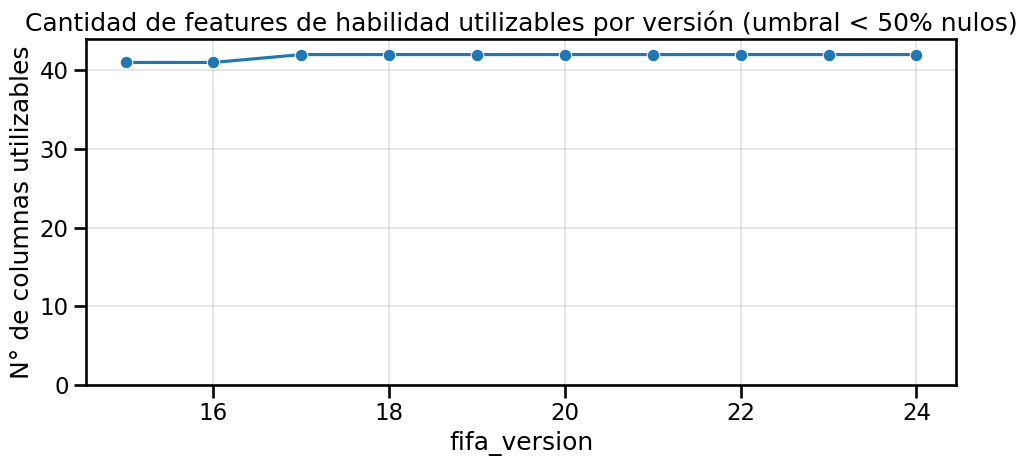

In [14]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=features_utilizables_por_version.index, y=features_utilizables_por_version.values, marker='o')
plt.title(f'Cantidad de features de habilidad utilizables por versión (umbral < {umbral}% nulos)')
plt.xlabel('fifa_version')
plt.ylabel('N° de columnas utilizables')
plt.ylim(0, len(habilidades_check) + 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Cantidad de jugadores por versión
jugadores_por_version = df.groupby('fifa_version')['player_id'].nunique()
jugadores_por_version

,player_id
fifa_version,
15.0,16182
16.0,16706
17.0,17596
18.0,17954
19.0,18086
20.0,18483
21.0,18892
22.0,19239
23.0,18533


In [16]:
# Evolución de los promedios a lo largo de las versiones
vars_clave = ['overall', 'potential', 'movement_sprint_speed', 'power_strength',
              'attacking_finishing', 'defending_standing_tackle']

medias_por_version = df.groupby('fifa_version')[vars_clave].mean().round(2)
medias_por_version

,overall,potential,movement_sprint_speed,power_strength,attacking_finishing,defending_standing_tackle
fifa_version,,,,,,
15.0,63.83,68.35,65.58,65.10,45.90,47.65
16.0,65.31,70.05,65.72,65.39,45.37,47.52
17.0,66.10,70.87,65.26,65.23,45.08,47.26
18.0,66.24,71.18,64.80,65.31,45.30,47.46
19.0,66.15,71.27,64.53,65.29,45.38,47.55
20.0,66.20,71.50,64.40,65.21,45.56,47.60
21.0,65.67,71.07,64.34,64.75,45.80,47.57
22.0,65.77,71.08,64.71,65.01,45.89,48.05
23.0,65.82,70.97,64.77,65.14,46.25,48.33


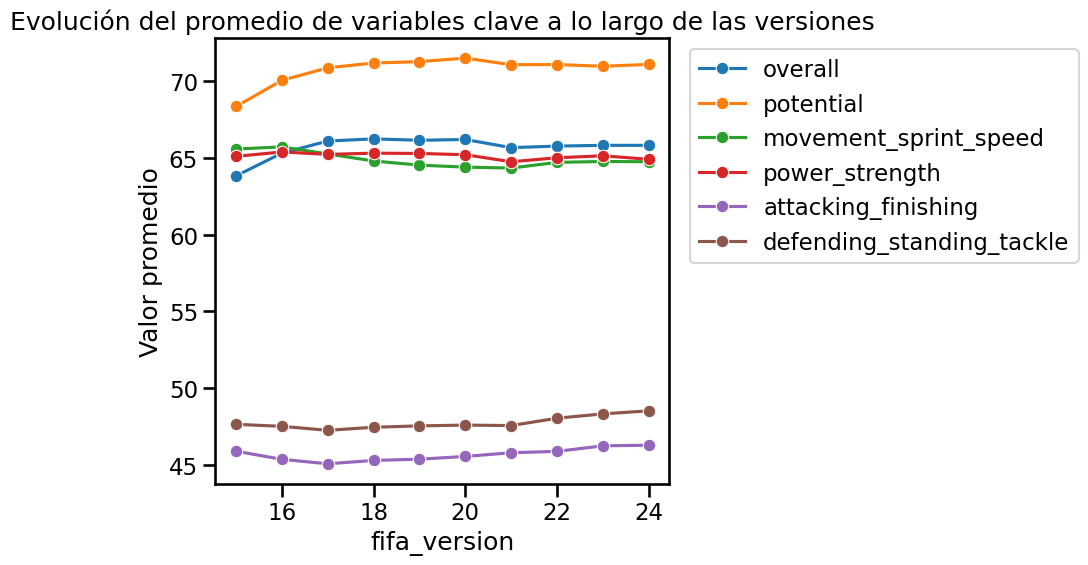

In [17]:
plt.figure(figsize=(10, 6))
for col in vars_clave:
    sns.lineplot(x=medias_por_version.index, y=medias_por_version[col], marker='o', label=col)
plt.title('Evolución del promedio de variables clave a lo largo de las versiones')
plt.xlabel('fifa_version')
plt.ylabel('Valor promedio')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Comentarios**

Disponibilidad de columnas: las 10 versiones son equivalentes en su estrucura de nulos. La gran mayoría de las columnas de `habilidades_check` están completas en todas las versiones. Las pocas excepciones responden a causas estructurales: `pace`, `shooting`, `dribbling`, `defending`y `physic`presentan nulos parejos en todas las versiones porque no aplican arqueros; `goalkeeping_speed` tiene un patrón inverso, con nulos parejos en arqueros, y `mentality_composure` recién se incorporó al videojuego a partir de la versión 17, por lo que está nula en las versiones anteriores.

Se observa que las versiones son consistentes entre sí, FC24 no pierde información estructural.

Se tiene en cuenta que al trabajar con la versión más reciente se pierde la evolución de un mismo jugador a lo largo de las versiones, lo cual es relevante para analizar trayectorias. Pero, en este caso el objetivo del trabajo es agrupar jugadores por habilidades equivalentes en un momento dado. Además, si bien FC24 no es la versión con mayor cantidad de jugadores, la diferencia es marginal y no justifica sacrificar actualidad de los datos.

In [18]:
# Filtro de versión
df_fc24_raw = df[df['fifa_version'] == 24].copy()
print("Filas:", df_fc24_raw.shape[0])
print("Jugadores únicos:", df_fc24_raw['player_id'].nunique())

Filas: 18350
Jugadores únicos: 18350


### **1.2. Selección de columnas relevantes y eliminación de redundantes**


Antes de descartar las variables económicas (`value_eur`, `wage_eur`, `release_clause_eur`), se evalúa su correlación con la habilidad global del jugador (`overall`, `potential`), ya que es esperable que el valor de mercado de un jugador esté relacionado con su nivel de juego.

In [19]:
# Correlación entre habilidad global y variables económicas
corr_economicas = df_fc24_raw[['overall','potential','value_eur','wage_eur','release_clause_eur']].corr()
corr_economicas

,overall,potential,value_eur,wage_eur,release_clause_eur
overall,1.000000,0.653449,0.554267,0.603202,0.542373
potential,0.653449,1.000000,0.514093,0.491471,0.524076
value_eur,0.554267,0.514093,1.000000,0.831595,0.995202
wage_eur,0.603202,0.491471,0.831595,1.000000,0.836658
release_clause_eur,0.542373,0.524076,0.995202,0.836658,1.000000


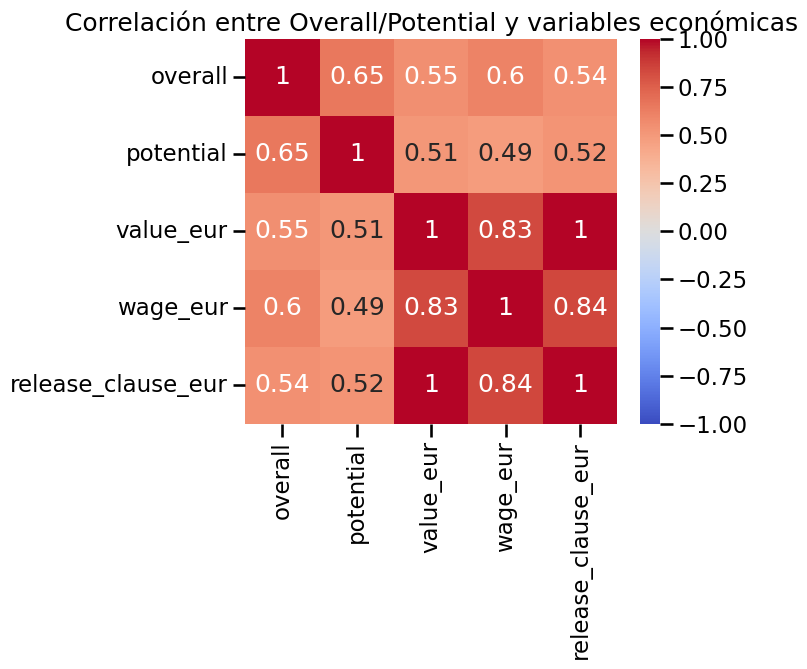

In [20]:
# Correlación
plt.figure(figsize=(6,5))
sns.heatmap(corr_economicas, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre Overall/Potential y variables económicas')
plt.show()

Se observa una correlación **moderada** entre `overall` y las variables económicas, es decir que el valor de mercado captura información redundante con la habilidad general del jugador.  Se decide excluirlas del vector de clustering ya que no aportan una dimensión de "habilidad" nueva, sino una variable derivada de mercado.


**Columnas a descartar:**

Se descartan identificadores, URLs, metadata de club/selección, texto libre y variables económicas, que no aportan al objetivo de agrupar jugadores por habilidades. Además, se eliminan como redundantes las variables resumen `pace`, `shooting`, `passing`, `dribbling`, `defending` y `physic`, ya que son un promedio de las variables detalladas de cada familia (`attacking_*`, `movement_*`, `power_*`, etc.) que sí se conservan.

In [21]:
# Columnas a descartar
useless_cols = ['player_url', 'fifa_update', 'update_as_of', 'long_name', 'value_eur',
               'wage_eur', 'dob', 'club_team_id', 'league_id', 'league_level', 'club_position',
               'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id',
               'nation_team_id', 'nation_jersey_number', 'international_reputation', 'real_face', 'release_clause_eur', 'player_tags',
               'player_traits','nation_position','pace','defending','physic','dribbling','passing','shooting']

In [22]:
# Se eliminan filas duplicadas
data_filtered = df_fc24_raw.drop_duplicates().copy()

# Se eliminan las columnas descartadas
df_fc24 = data_filtered.drop(columns=useless_cols)
print(f"Filas: {df_fc24.shape[0]:,} | Columnas: {df_fc24.shape[1]}")

Filas: 18,350 | Columnas: 79


In [23]:
clean_resume = pd.DataFrame(
    {
        'Tipo': df_fc24.dtypes,
        'No Nulos': df_fc24.notna().sum(),
        'Nulos': df_fc24.isnull().sum(),
        '% Nulos': (df_fc24.isnull().sum() / len(df_fc24) * 100).round(2),
        'Únicos': df_fc24.nunique(),
        'Ejemplo': df_fc24.iloc[0],
    }
)
display(clean_resume.sort_values(by='% Nulos', ascending=False))

,Tipo,No Nulos,Nulos,% Nulos,Únicos,Ejemplo
goalkeeping_speed,float64,2045,16305,88.86,51,NaN
club_name,object,18263,87,0.47,670,Paris Saint Germain
league_name,object,18263,87,0.47,40,Ligue 1
player_positions,object,18350,0,0.00,711,"ST, LW"
overall,int64,18350,0,0.00,45,91
fifa_version,float64,18350,0,0.00,1,24.0
player_id,int64,18350,0,0.00,18350,231747
age,int64,18350,0,0.00,28,24
potential,int64,18350,0,0.00,47,94
weight_kg,int64,18350,0,0.00,55,75


Se observa que de las columnas conservadas, tres tienen valores nulos presentes. El 88.86 % de valores nulos en  `goalkeeping_speed` indica que la categoría no corresponde a la mayoría de los jugadores registrados, ya que esa característica es exclusiva de arqueros. Podría imputarse con cero, pero eso tendría repercusiones negativas en el clustering:

- Sesgo por valor dominante: más del 88% del dataset tendría valor de 0 en esa variable.
- Efecto en el escalado: al aplicar StandarScaler o MinMaxScaler, se distorsionará la varianza.

Se opta por eliminar este feature de la lista de skills para hacer el clustering, con el fin de lograr mejor resultado en la clasificación de jugadores de campo.

Por otro lado, `club_name` y `league_name` tiene un 0.47% de nulos (jugadores sin club/liga en esta versión). Al ser un % marginal y tratarse de variables categóricas que no forman parte de las skills usadas para clustering, se imputan con la etiqueta de `"Sin club"` / `"Sin liga"` en vez de descartar esas filas.

In [24]:
skills = ['attacking_crossing','attacking_finishing',
          'attacking_heading_accuracy','attacking_short_passing','attacking_volleys','skill_dribbling', 'skill_curve',
          'skill_fk_accuracy','skill_long_passing','skill_ball_control','movement_acceleration','movement_sprint_speed',
          'movement_agility','movement_reactions','movement_balance','power_shot_power','power_jumping','power_stamina',
          'power_strength','power_long_shots','mentality_aggression','mentality_interceptions','mentality_positioning',
          'mentality_vision','mentality_penalties','mentality_composure','defending_marking_awareness','defending_standing_tackle',
          'defending_sliding_tackle','goalkeeping_handling','goalkeeping_diving','goalkeeping_kicking','goalkeeping_positioning',
          'goalkeeping_reflexes']

forwards=['RF','ST','LW','LF','RS','LS','RW','CF']
midfielders=['RCM','LCM','LDM','CAM','CDM','LAM','RDM','CM','RAM','RM','LM']
defenders=['RCB','CB','LCB','LB','RB','RWB','LWB']
goalkeepers=['GK']

Para simplificar la visualización y caracterización de clusters, se agrupan las posiciones específicas de `player_positions` en 4 macro-categorías futbolísticas: Delantero (`Forward`), Mediocampista (`Midfielder`), Defensor (`Defender`) y Arquero (`GK`).

Se toma como posición principal la primera indicada en `player_positions` para los jugadores con múltiples posiciones habilitadas.

In [25]:
df_fc24['principal_position'] = df_fc24['player_positions'].str.split(',').str[0].str.strip()

pos_map = {
    **{p: 'Forward' for p in forwards},
    **{p: 'Midfielder' for p in midfielders},
    **{p: 'Defender' for p in defenders},
    **{p: 'GK' for p in goalkeepers}
}

df_fc24['position'] = df_fc24['principal_position'].map(pos_map).fillna('nan')
df_fc24['position'].value_counts()

,count
position,
Midfielder,6673
Defender,6174
Forward,3458
GK,2045


La agrupación en 4 categorías se encuentra sin valores `'nan'` (todas las posiciones del dataset quedaron cubiertas por `pos_map`).

La variable `position` se usa para las visualizaciones categóricas, y sirve como referencia externa para validar cualitativamente los clusters de habilidad, sin haber sido usada como feature de clustering en sí misma.

### **1.3. Tratamiento de valores faltantes y duplicados**



Como se mencionó al comienzo, el dataset combina 10 versiones del juego por jugador, y ya se  filtró a una versión más reciente (FC24) antes de la selección de columnas, de modo que cada jugador quede representado una sola vez con sus atributos actuales.

A continuación se verifica que no queden duplicados ni valores faltantes sin resolver.

In [26]:
# Duplicados sobre todas las columnas
print("Filas duplicadas exactas:", df_fc24.duplicated().sum())

# Duplicados por jugador
print("player_id  duplicados:", df_fc24['player_id'].duplicated().sum())

Filas duplicadas exactas: 0
player_id  duplicados: 0


In [27]:
# Tabla de faltantes
faltantes = pd.DataFrame({
    'n_faltantes': df_fc24.isnull().sum(),
    'pct_faltantes': (df_fc24.isnull().mean()*100).round(2)
}).sort_values('pct_faltantes', ascending=False)
faltantes[faltantes['n_faltantes'] > 0]

,n_faltantes,pct_faltantes
goalkeeping_speed,16305,88.86
club_name,87,0.47
league_name,87,0.47


In [28]:
# Imputación de club/liga faltantes
df_fc24['club_name'] = df_fc24['club_name'].fillna('Sin club')
df_fc24['league_name'] = df_fc24['league_name'].fillna('Sin liga')

# Verificación
df_fc24[['club_name','league_name']].isnull().sum()

,0
club_name,0
league_name,0


El análisis de faltantes indica que `goalkeeping_speed` concentra 88.86% de los nulos, por lo que fue excluida de la lsita de skills usada para el clustering.


### **1.4. Estadística descriptiva de las variables numéricas relevantes**

Se analizan las medidas de tendencia central y dispersión de las variables de `skills` y de las variables generales de desempeño.

In [29]:
df_skills = df_fc24[skills].copy()
df_skills.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
attacking_crossing,18350.0,49.29,17.83,7.0,39.0,53.0,63.0,95.0
attacking_finishing,18350.0,46.29,19.73,3.0,31.0,50.0,62.0,96.0
attacking_heading_accuracy,18350.0,51.79,17.30,5.0,44.0,55.0,64.0,93.0
attacking_short_passing,18350.0,59.06,14.33,10.0,54.0,62.0,68.0,94.0
attacking_volleys,18350.0,42.44,17.59,4.0,30.0,44.0,56.0,91.0
skill_dribbling,18350.0,55.95,18.77,4.0,51.0,62.0,68.0,96.0
skill_curve,18350.0,47.75,17.90,7.0,36.0,50.0,61.0,93.0
skill_fk_accuracy,18350.0,42.74,16.89,5.0,31.0,42.0,55.0,94.0
skill_long_passing,18350.0,53.64,14.65,10.0,45.0,56.0,64.0,94.0
skill_ball_control,18350.0,58.63,16.65,9.0,55.0,63.0,69.0,94.0


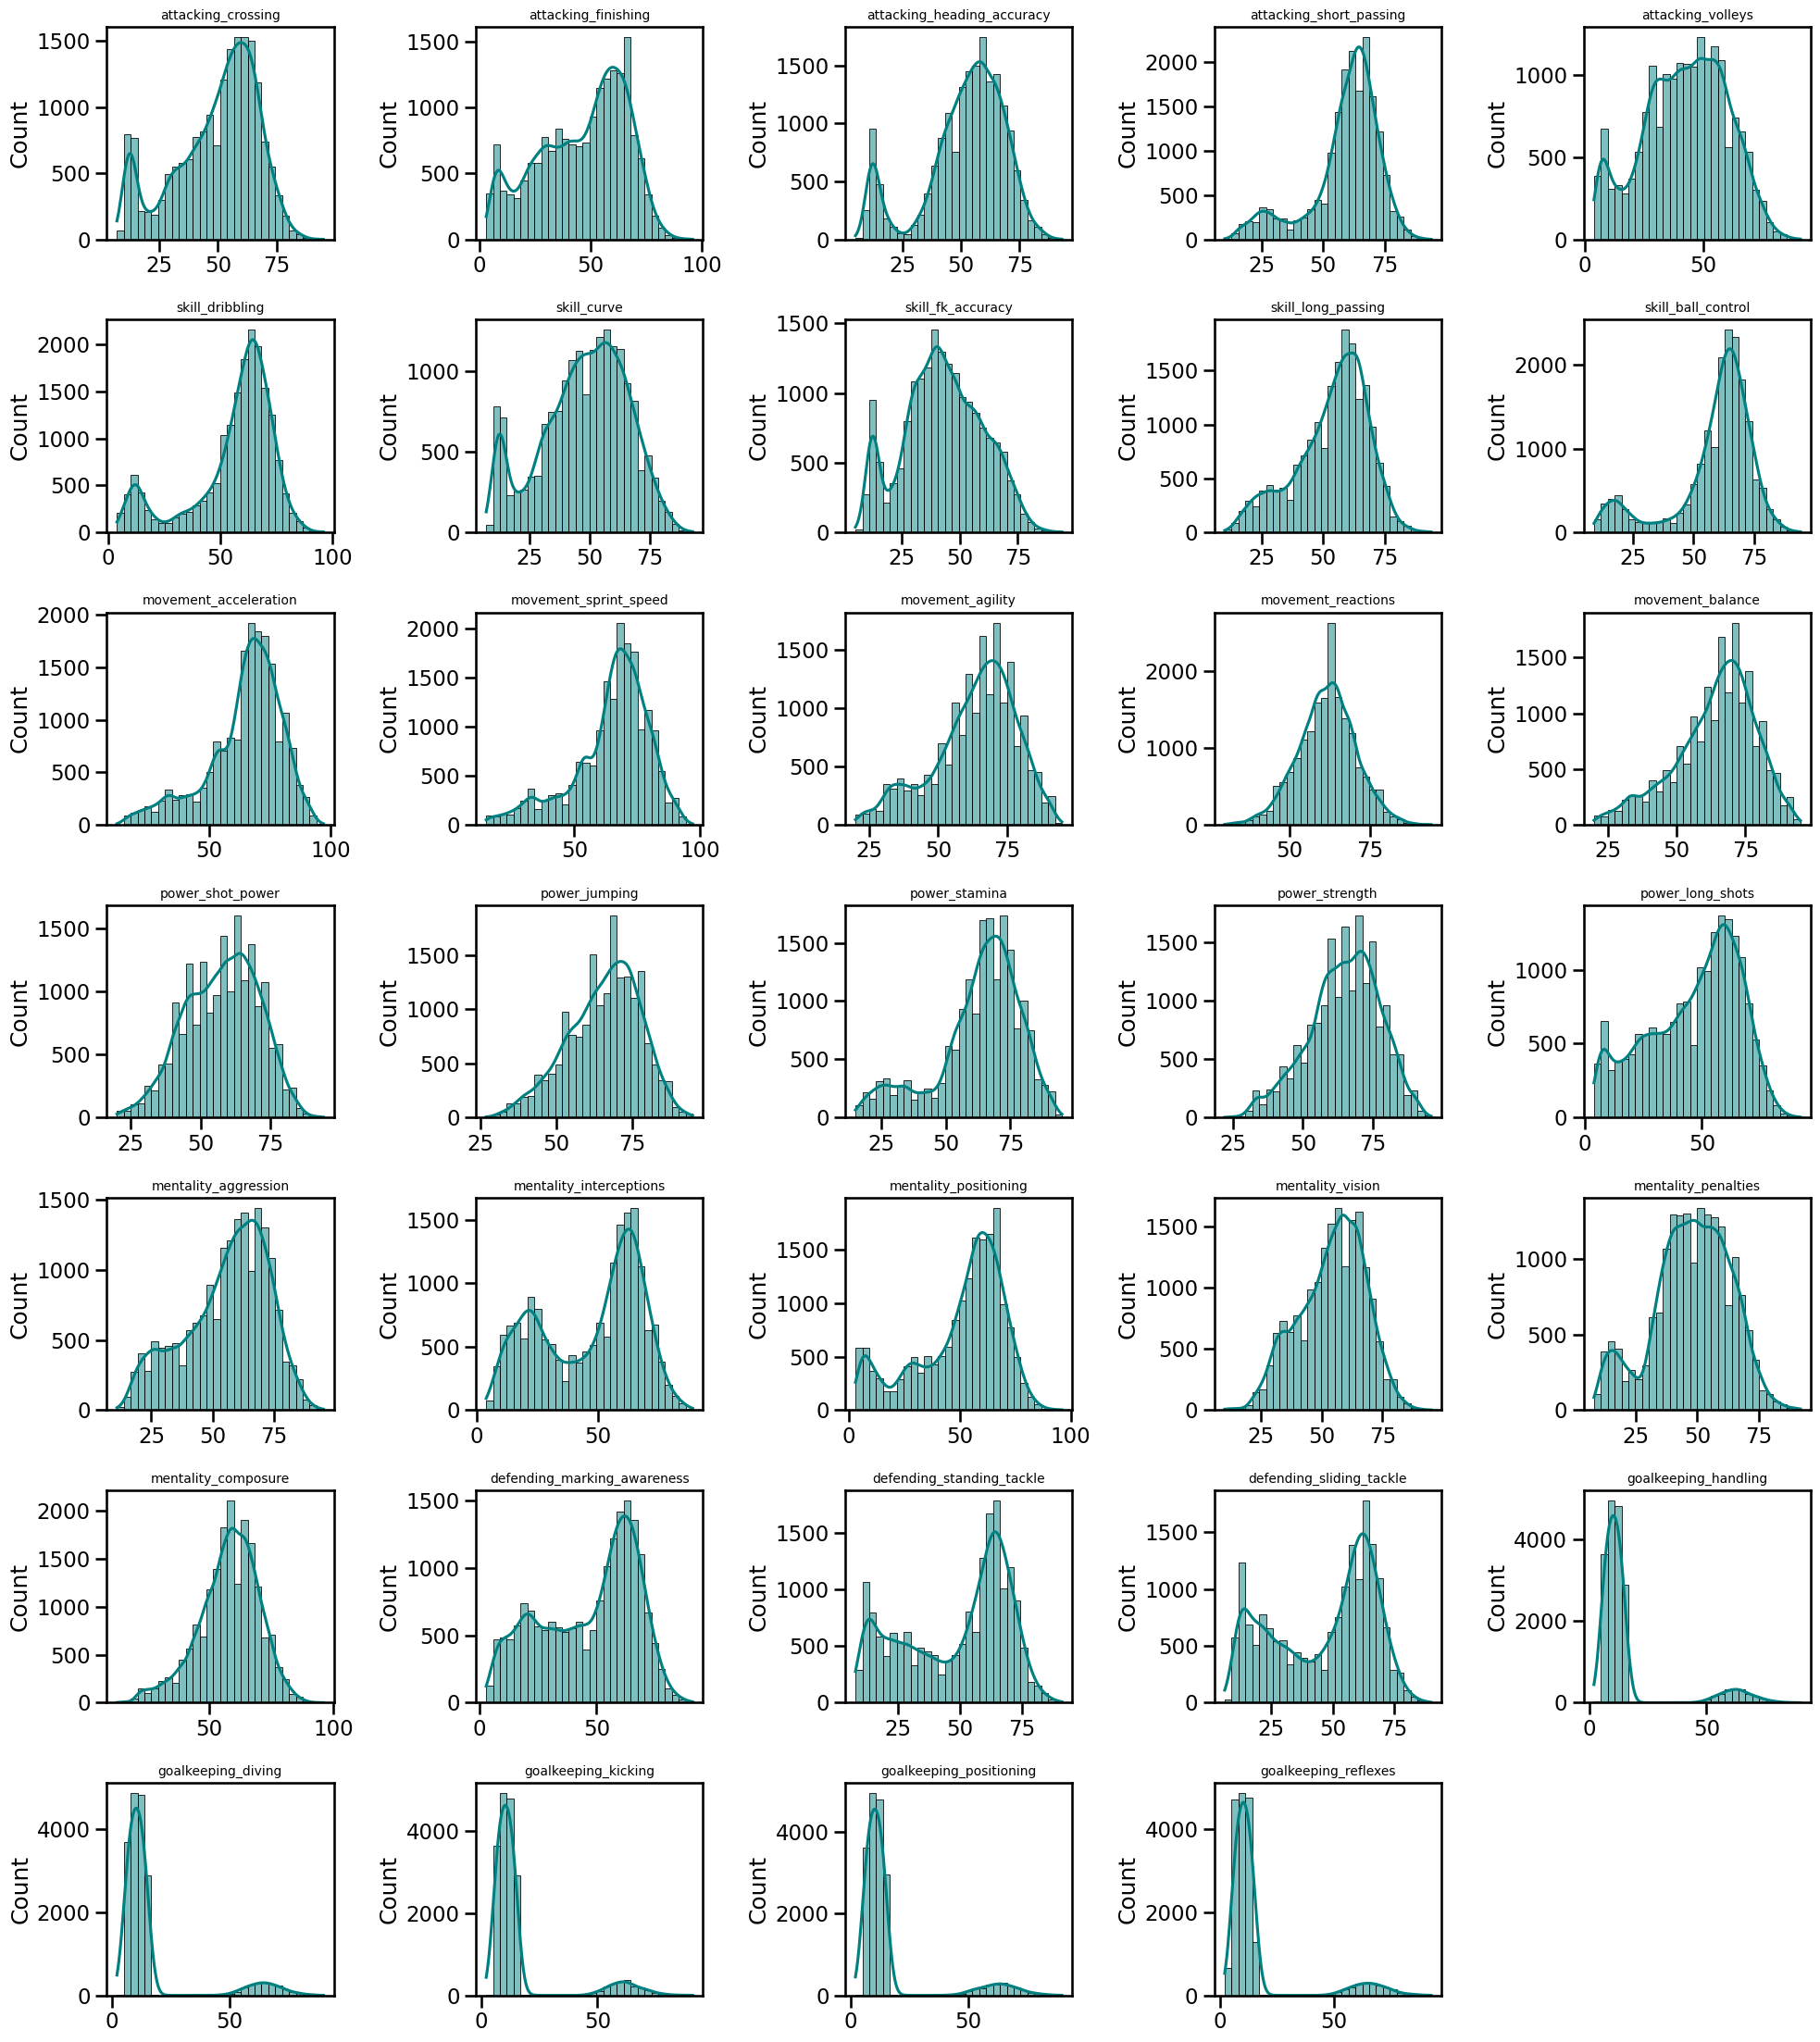

In [30]:
# Histogramas de las variables de skill
n_cols = 5
n_rows = -(-len(skills) // n_cols)  # división hacia arriba

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(skills):
    sns.histplot(df_skills[col], bins=30, ax=axes[i], color='teal', kde=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Ocultar subplots vacíos sobrantes (33 variables no llenan la grilla completa)
for j in range(len(skills), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

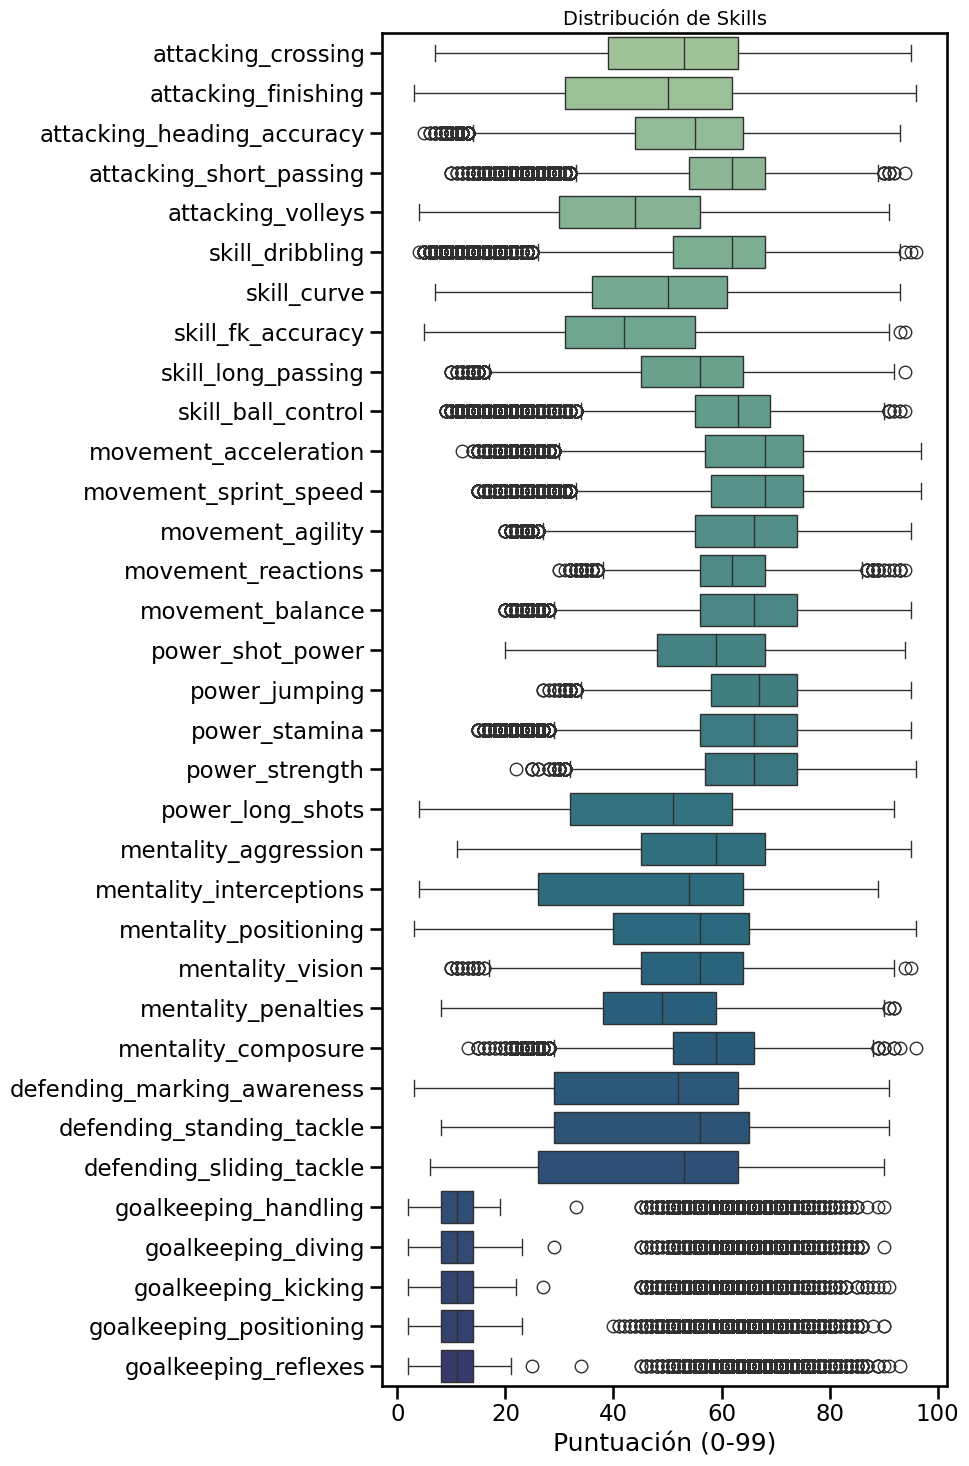

In [31]:
# Visualizacion en boxplot de las skills
plt.figure(figsize=(10, 15))
sns.boxplot(data=df_skills, orient="h", palette="crest")
plt.title("Distribución de Skills", fontsize=14)
plt.xlabel("Puntuación (0-99)")
plt.tight_layout()
plt.show()

In [32]:
# Resumen de variables generales (no incluidas en 'skills')
resumen_vars = ['overall','potential','age','height_cm','weight_kg']
df_fc24[resumen_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
overall,18350.0,65.817057,6.817917,47.0,62.0,66.0,70.0,91.0
potential,18350.0,71.088065,6.220982,48.0,67.0,71.0,75.0,94.0
age,18350.0,25.267139,4.757756,16.0,21.0,25.0,29.0,43.0
height_cm,18350.0,181.698747,6.869995,156.0,177.0,182.0,187.0,206.0
weight_kg,18350.0,75.210354,6.985703,49.0,70.0,75.0,80.0,105.0


In [33]:
# Caso 1: jugadores con valores extremos de edad
print("Jugador más joven:")
print(df_fc24.loc[df_fc24['age'].idxmin(), ['short_name','age','overall','club_name']])
print("\nJugador más grande:")
print(df_fc24.loc[df_fc24['age'].idxmax(), ['short_name','age','overall','club_name']])

Jugador más joven:
short_name    G. Ilenikhena
age                      16
overall                  61
club_name           Antwerp
Name: 13801, dtype: object

Jugador más grande:
short_name        S. Lukić
age                     43
overall                 61
club_name     Varberg BoIS
Name: 14451, dtype: object


In [34]:
# Caso 2: extremos de altura/peso
print(df_fc24.nsmallest(5, 'height_cm')[['short_name','height_cm','weight_kg','player_positions']])
print()
print(df_fc24.nlargest(5, 'height_cm')[['short_name','height_cm','weight_kg','player_positions']])

        short_name  height_cm  weight_kg player_positions
1952    N. Barrios        156         58          LW, CAM
8325      B. Oyola        156         58      RM, RW, CAM
8731     J. Nisbet        158         58           CM, RM
1610    M. Moralez        159         54      CAM, CM, CF
4994  V. Hernández        160         59      LM, CAM, RM

        short_name  height_cm  weight_kg player_positions
4337      I. Touré        206         98               CB
13621      T. Holý        206        102               GK
15971  K. Gadellaa        206         92               GK
16119    K. Hudlin        206         85               ST
16323  T. Hülsmann        205         89               GK


En síntesis, las variables de `skills` se comportan dentro del rango esperado (0-99), salvo las de `goalkeeping_*`, que muestran una distribución con diferencia entre arqueros y jugadores de campo. Las variables generales (`age`, `height_cm`, `weight_kg`, `overall`, `potential`) no presentan valores fuera de rangos razonables para el fútbol profesional, y los casos extremos identificados (jugador más joven/mayor, más bajo/alto) resultan consistentes con la posición y el tipo de perfil de cada jugador, sin indicios de errores de carga en los datos.

### **1.5. Distribución de las principales variables categóricas: posición, liga y nacionalidad.**

a) Posición: player_position: esta columna trae múltiples posiciones separadas por coma, se mira la posición principal como el conteo de combinaciones.


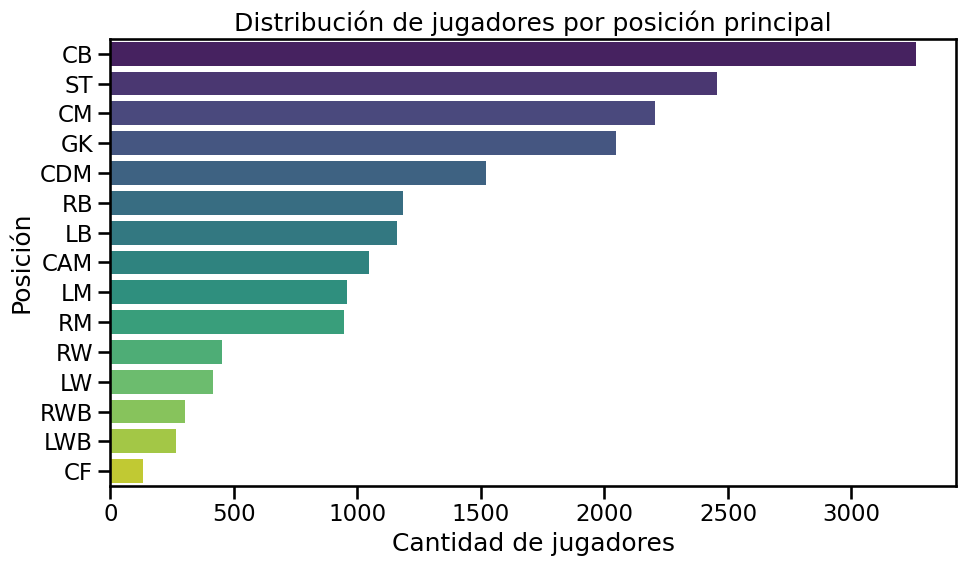

In [35]:
# Player_position
plt.figure(figsize=(10,6))
orden = df_fc24['principal_position'].value_counts().index
sns.countplot(y='principal_position', data=df_fc24, order=orden, palette='viridis')
plt.title('Distribución de jugadores por posición principal')
plt.xlabel('Cantidad de jugadores')
plt.ylabel('Posición')
plt.tight_layout()
plt.show()

In [36]:
df_fc24['principal_position'].value_counts()

,count
principal_position,
CB,3260
ST,2457
CM,2204
GK,2045
CDM,1519
RB,1186
LB,1162
CAM,1049
LM,957


Hay más defensores centrales (CB) que cualquier otra posición seguido de delanteros (ST), y volantes centrales (CM), tiene sentido porque los equipos suelen tener 2-3 CB pero 1 arquero titular.

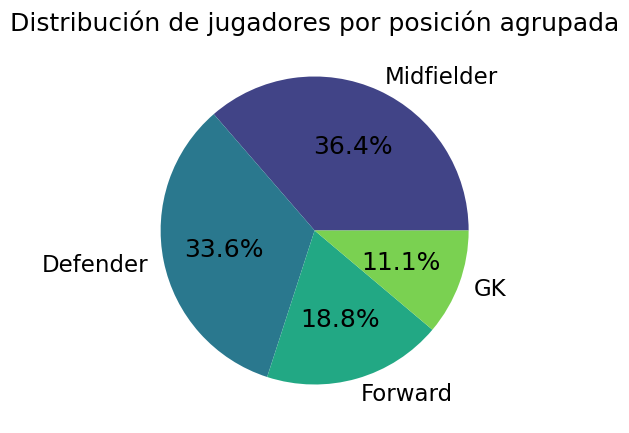

In [37]:
# Distribución de jugadores
plt.figure(figsize=(6,5))
df_fc24['position'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('viridis', 4))
plt.title('Distribución de jugadores por posición agrupada')
plt.ylabel('')
plt.show()

Al agrupar en las 4 macro-posiciones, los defensores (`Defender`) son la categoría más numerosa —consistente con que los equipos suelen alinear 3-4 defensores por 1 arquero—, seguidos por mediocampistas y delanteros en proporciones similares, y los arqueros como grupo más chico. Esta variable agrupada es la que se usará más adelante para contrastar cualitativamente los clusters de habilidad (sección 5).

b) Liga (league_name)

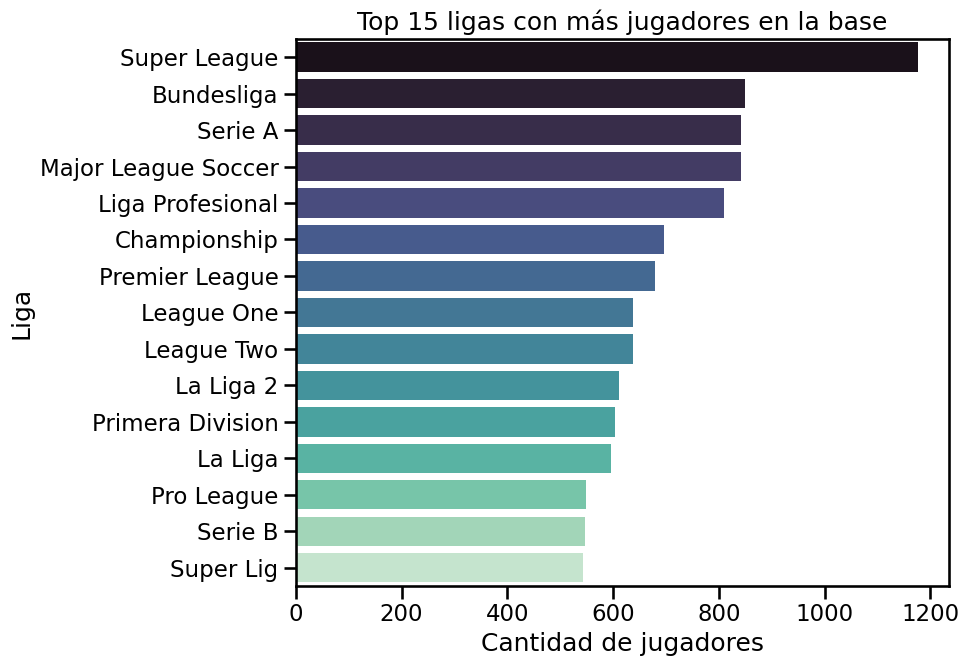

In [38]:
# Ligas
top_ligas = df_fc24['league_name'].value_counts().head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top_ligas.values, y=top_ligas.index, palette='mako')
plt.title('Top 15 ligas con más jugadores en la base')
plt.xlabel('Cantidad de jugadores')
plt.ylabel('Liga')
plt.tight_layout()
plt.show()

La distribución se encuentra repartida entre las top 15, liderando Super League, seguida de Bundesliga y Serie A.

Ninguna liga concentra desproporcionadamente la base, lo cual es bueno para que el clustering no esté sesgado.

c) Nacionalidad (nationality_name)

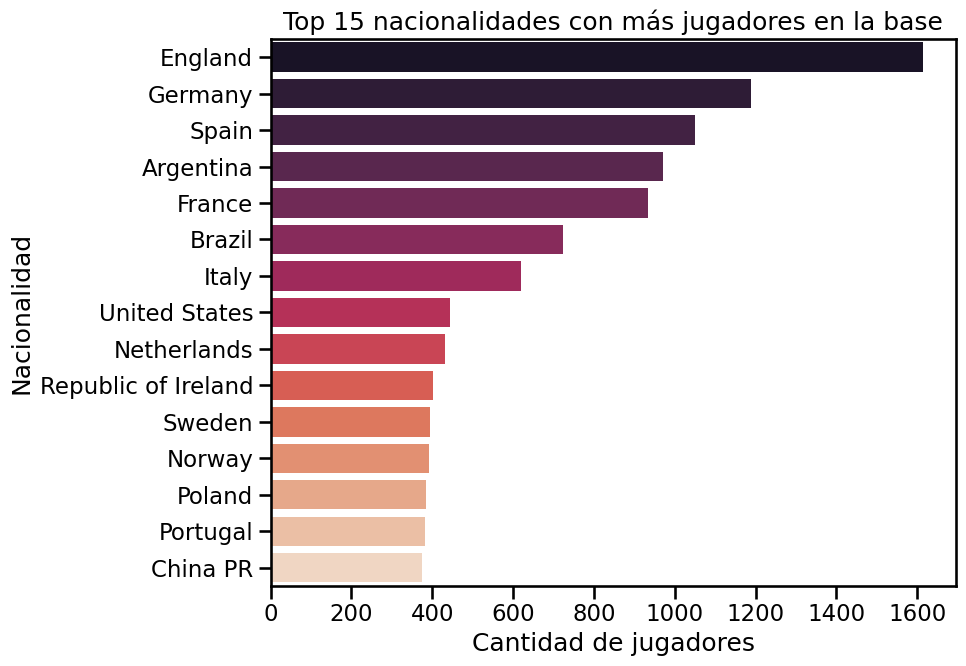

In [39]:
# Nacionalidades
top_nac = df_fc24['nationality_name'].value_counts().head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top_nac.values, y=top_nac.index, palette='rocket')
plt.title('Top 15 nacionalidades con más jugadores en la base')
plt.xlabel('Cantidad de jugadores')
plt.ylabel('Nacionalidad')
plt.tight_layout()
plt.show()

Inglaterra lidera, seguida de Alemania y España. Inglaterra lidera ya que tiene muchísimas divisiones en el dataset.

e) Pie hábil (preferred_foot)

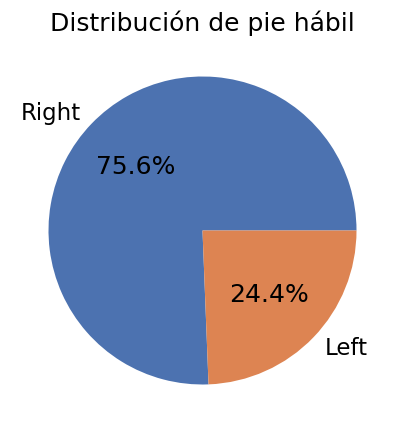

In [40]:
# Pie hábil
plt.figure(figsize=(5,5))
df_fc24['preferred_foot'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0','#DD8452'])
plt.title('Distribución de pie hábil')
plt.ylabel('')
plt.show()

f) Distribución de edad

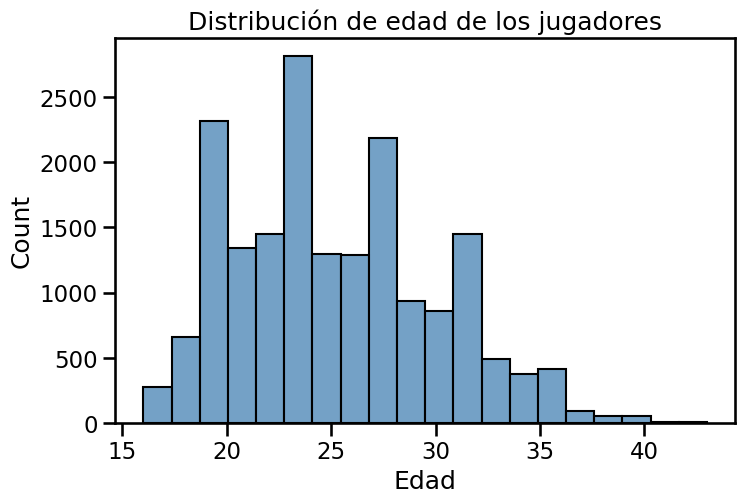

In [41]:
# Distribución de edad
plt.figure(figsize=(8,5))
sns.histplot(df_fc24['age'], bins=20, color='steelblue')
plt.title('Distribución de edad de los jugadores')
plt.xlabel('Edad')
plt.show()

g) Ritmo de trabajo ataque / defensa

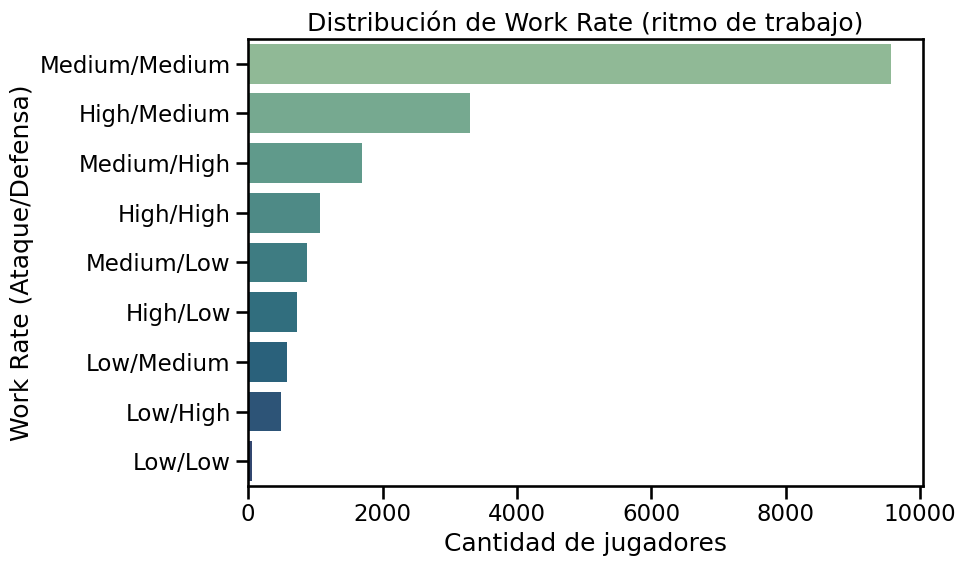

In [42]:
# Ritmo de juego
plt.figure(figsize=(10,6))
orden_wr = df_fc24['work_rate'].value_counts().index
sns.countplot(y='work_rate', data=df_fc24, order=orden_wr, palette='crest')
plt.title('Distribución de Work Rate (ritmo de trabajo)')
plt.xlabel('Cantidad de jugadores')
plt.ylabel('Work Rate (Ataque/Defensa)')
plt.tight_layout()
plt.show()

h) Habilidad de trucos

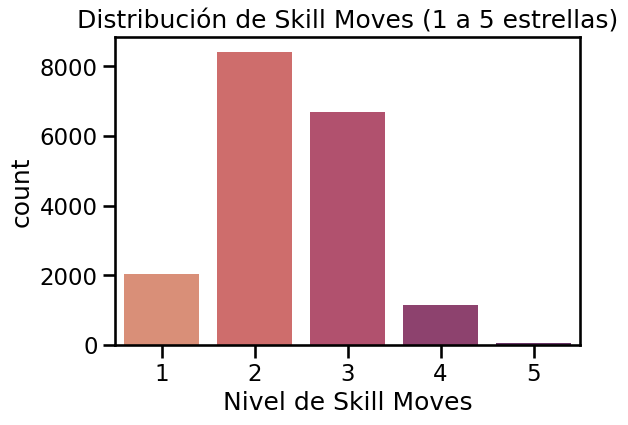

In [43]:
# Habilidad de trucos
plt.figure(figsize=(6,4))
sns.countplot(x='skill_moves', data=df_fc24, palette='flare')
plt.title('Distribución de Skill Moves (1 a 5 estrellas)')
plt.xlabel('Nivel de Skill Moves')
plt.show()

Las variables categóricas muestran una base balanceada, en la que las posiciones y ligas están bien distribuidas sin una categoría dominante que sesgue el clustering, la nacionalidad refleja donde se concentra la mayoría de las ligas, y variables como pie hábil, work rate y skill moves aportan información complementaria útil para caracterizar a los jugadores dentro de cada cluster, más allá de las habilidades numéricas.

## **2. Evaluación visual e intuitiva de dos variables numéricas por vez**

Se seleccionaron pares de variables estratégicas con lógica táctica opuesta para verificar la separación visual de los datos según las cuatro posiciones macro.

Los pares elegidos comparan:

- Técnica: ataque vs defensa,
- Físico: Velocidad vs fuerza,
- Actitud: Visión vs intercepción

Previo a la visualización, se asigna una codificación de color exclusiva para cada posición con el fin de distinguir con claridad los distintos grupos.

In [44]:
# Parametros de la muestra
#df_sample = df_fc24.sample(n=5000, random_state=42)
paleta_pos = {
    'Forward': '#e74c3c',
    'Midfielder': '#f1c40f',
    'Defender': '#3498db',
    'GK': '#2ecc71',
}

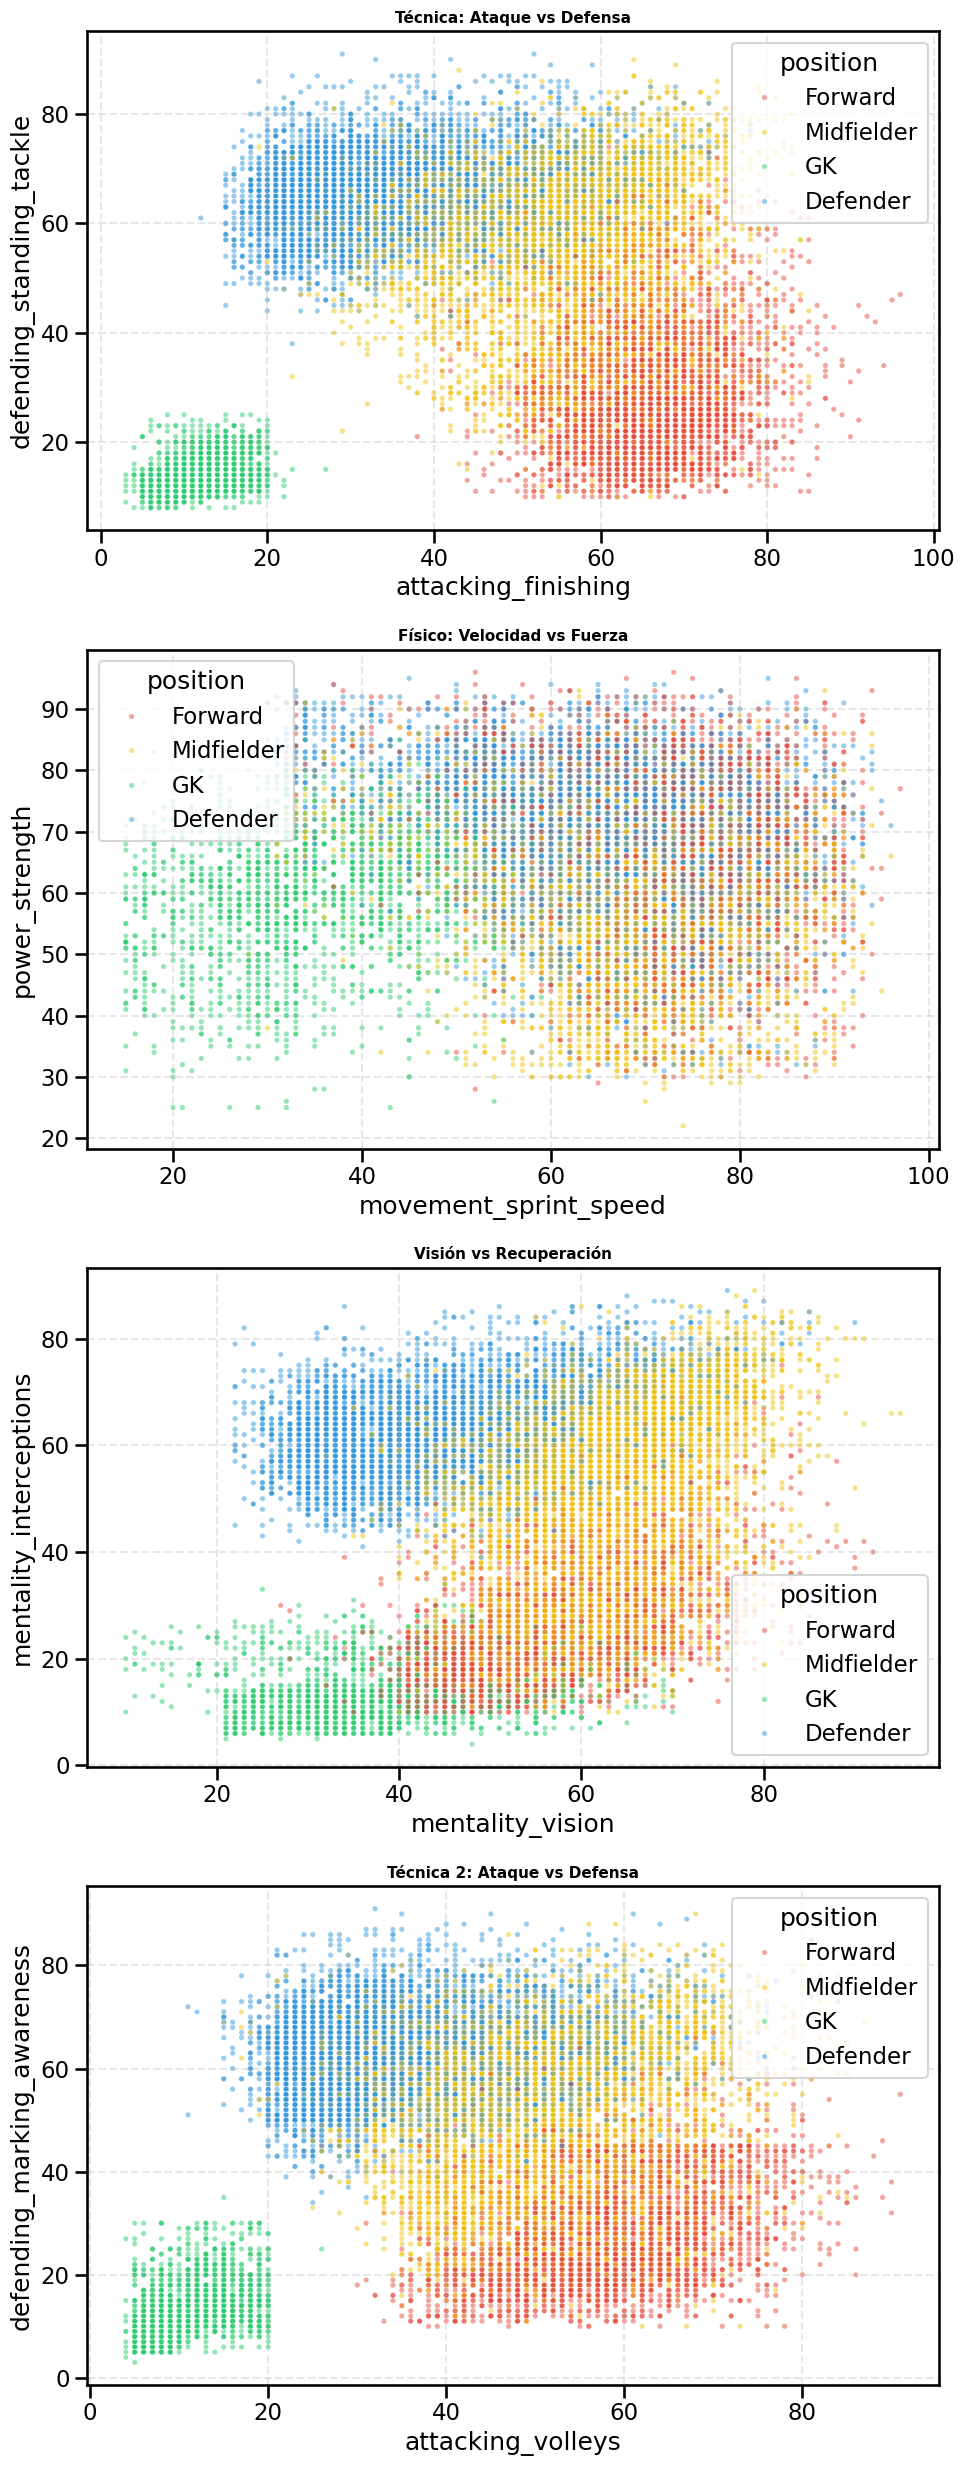

In [45]:
# Definicion de pares de variables con sentido intuitivo
pares_estrategicos = [
    (
        'attacking_finishing',
        'defending_standing_tackle',
        'Técnica: Ataque vs Defensa',
    ),
    (
        'movement_sprint_speed',
        'power_strength',
        'Físico: Velocidad vs Fuerza',
    ),
    (
        'mentality_vision',
        'mentality_interceptions',
        'Visión vs Recuperación',
    ),
    (
        'attacking_volleys',
        'defending_marking_awareness',
        'Técnica 2: Ataque vs Defensa',
    ),
]

# Renderizado de gráficos 2 a 2
fig, axes = plt.subplots(4, 1, figsize=(10, 25))

for i, (var_x, var_y, titulo) in enumerate(pares_estrategicos):
    sns.scatterplot(
        data=df_fc24,
        x=var_x,
        y=var_y,
        hue='position',
        palette=paleta_pos,
        alpha=0.5,
        s=15,
        ax=axes[i],
    )
    axes[i].set_title(f'{titulo}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(var_x)
    axes[i].set_ylabel(var_y)
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Las variables **técnicas** demostraron la mayor capacidad para discriminar a los jugadores según su posición táctica. Por el contrario, los atributos **físicos** responden a un perfil individual con alto solapamiento entre posiciones, resultando poco determinantes para el agrupamiento posicional.

Se realiza una segunda exploración compacta para identificar otras combinaciones convenientes:

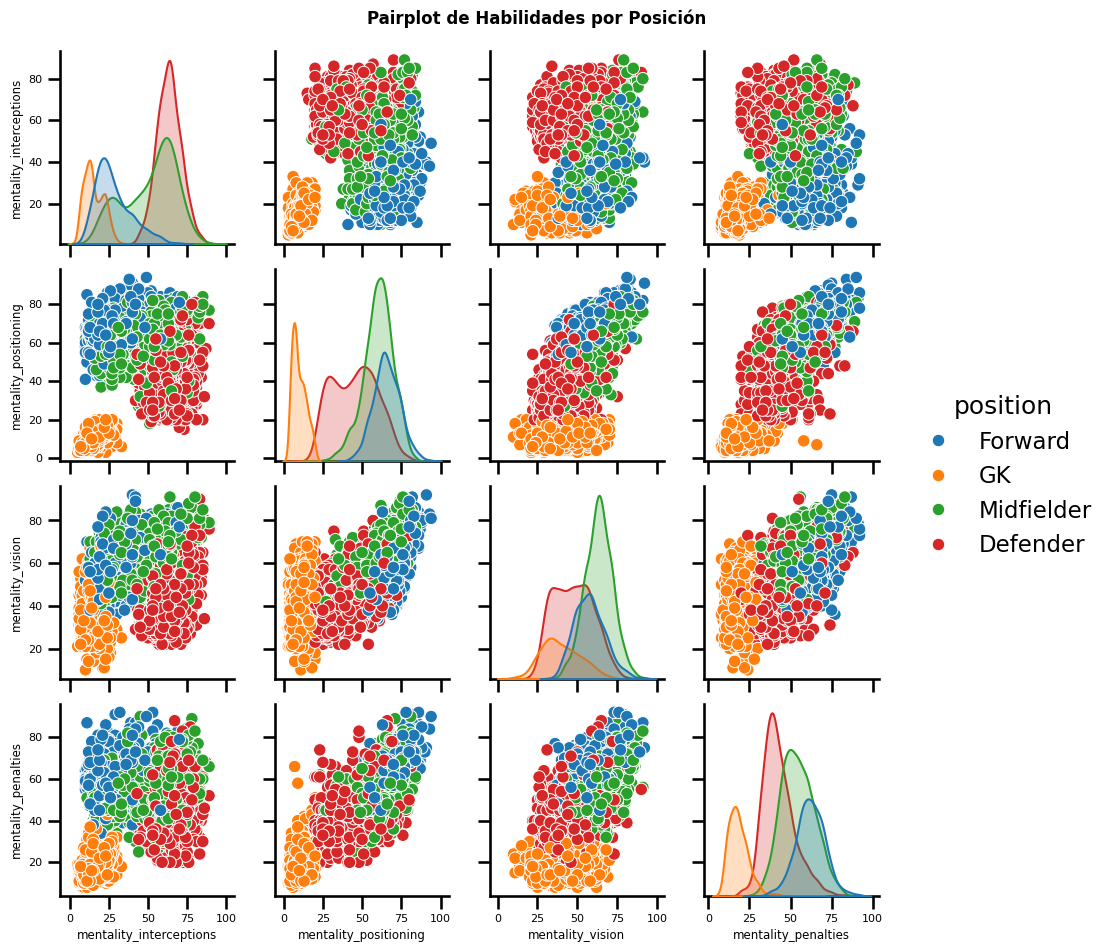

In [46]:
# Muestra de datos
otros_pares = [
    'mentality_interceptions',
    'mentality_positioning',
    'mentality_vision',
    'mentality_penalties',
    'position',
]
df_sample = df_fc24.sample(n=5000, random_state=42)

# Crear pairplot
g = sns.pairplot(
    df_sample[otros_pares], hue='position', diag_kind='kde', height=2.4
)

# Ajustar el tamaño del texto
for ax in g.axes.flat:
    if ax:
        ax.xaxis.label.set_size(8.5)  # Nombre de variable en X
        ax.yaxis.label.set_size(8.5)  # Nombre de variable en Y
        ax.tick_params(labelsize=8)   # Valores de los ejes

g.fig.suptitle(
    'Pairplot de Habilidades por Posición', y=1.02, fontsize=12, fontweight='bold'
)

plt.show()

Se observa que _postioning_ junto a _interceptions_ es una buena combinación. El desempeño de los demás pares no permite un agrupamiento posicional claro.

## **3. Pregunta: ¿Se realizó alguna normalización o escalado de la base? ¿Por qué?**



Se aplica estandarización (Z-score) mediante StandardScaler. Aunque la mayoría de las skills comparten un rango teórico de 0 a 99, sus distribuciones reales presentan medias y varianzas muy diferentes. Sin estandarizar, las habilidades con mayor dispersión (alta varianza) dominarían desproporcionadamente el cálculo de las distancias euclídeas en algoritmos como K-Means o Ward, opacando a las variables más concentradas.

Se opta por Z-score porque iguala la varianza de todas las dimensiones (std=1) y centra los datos (media=0) manteniendo intacta la forma lineal de sus distribuciones originales.

In [47]:
# Aplicamos estandarización (z-score)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_skills)
df_scaled = pd.DataFrame(X_scaled, columns=skills, index=df_skills.index)

df_scaled.describe().T[['mean','std','min','max']]

,mean,std,min,max
attacking_crossing,-9.912749e-17,1.000027,-2.372210,2.563876
attacking_finishing,-4.956374e-17,1.000027,-2.194490,2.519502
attacking_heading_accuracy,1.239094e-17,1.000027,-2.705427,2.382305
attacking_short_passing,-1.734731e-16,1.000027,-3.424579,2.438955
attacking_volleys,-1.982550e-16,1.000027,-2.184774,2.760501
skill_dribbling,1.363003e-16,1.000027,-2.767170,2.133142
skill_curve,6.195468e-17,1.000027,-2.277079,2.528474
skill_fk_accuracy,2.478187e-17,1.000027,-2.234037,3.034884
skill_long_passing,-1.610822e-16,1.000027,-2.978427,2.754653
skill_ball_control,-1.486912e-16,1.000027,-2.980813,2.124097


Se usa StandardScaleraún siendo sensible a valores atípicos (como las métricas de arqueros frente a jugadores de campo). Como nuestro objetivo es precisamente que el clustering detecte estas anomalías como grupos separados, conservar el impacto de estos valores extremos es deseable.

A continuación se presenta un gráfico que evidencia cómo cambió la varianza antes y después de la estandarización para 2 variables concretas:

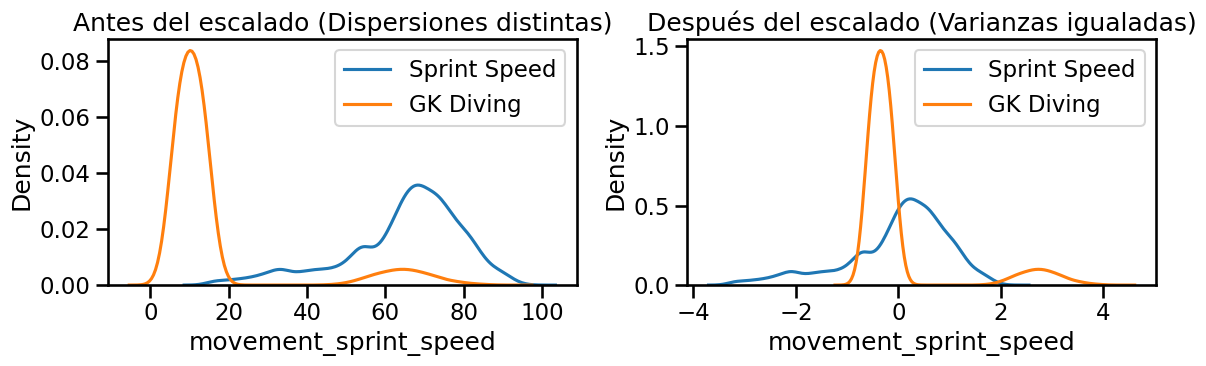

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mostrar cómo una variable con mucha varianza domina a una con poca antes del escalado
sns.kdeplot(df_skills['movement_sprint_speed'], ax=axes[0], label='Sprint Speed')
sns.kdeplot(df_skills['goalkeeping_diving'], ax=axes[0], label='GK Diving')
axes[0].set_title('Antes del escalado (Dispersiones distintas)')
axes[0].legend()

# Mostrar cómo ahora son comparables
sns.kdeplot(df_scaled['movement_sprint_speed'], ax=axes[1], label='Sprint Speed')
sns.kdeplot(df_scaled['goalkeeping_diving'], ax=axes[1], label='GK Diving')
axes[1].set_title('Después del escalado (Varianzas igualadas)')
axes[1].legend()

plt.tight_layout()
plt.show()


## **4. Aplicación de clustering.**


4.1 Método del codo + silueta para elegir k (KMeans)

n_clusters=2 | inertia=333133.1 | silhouette=0.5727
n_clusters=3 | inertia=254648.4 | silhouette=0.2700
n_clusters=4 | inertia=211576.0 | silhouette=0.2670
n_clusters=5 | inertia=191610.3 | silhouette=0.2507
n_clusters=6 | inertia=177483.0 | silhouette=0.2251
n_clusters=7 | inertia=171067.3 | silhouette=0.1835
n_clusters=8 | inertia=161161.3 | silhouette=0.1750
n_clusters=9 | inertia=152177.1 | silhouette=0.1721
n_clusters=10 | inertia=146808.4 | silhouette=0.1669


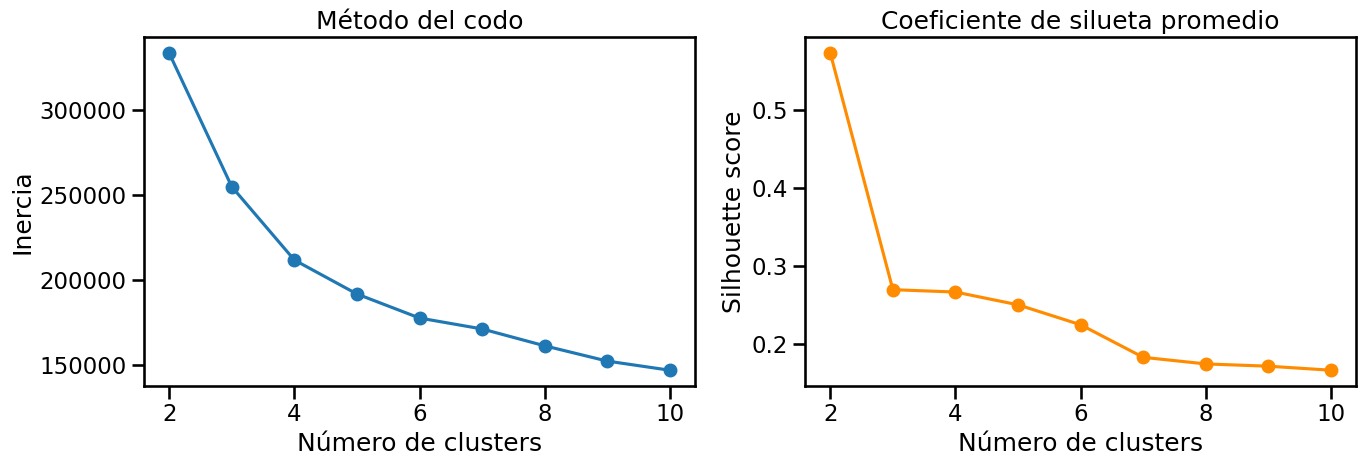

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

range_n_clusters = range(2, 11)
inertias = []
silhouette_scores = []

for n_clusters in range_n_clusters:
    km_tmp = KMeans(n_clusters=n_clusters, random_state=42)
    labels_tmp = km_tmp.fit_predict(df_scaled)
    inertias.append(km_tmp.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels_tmp))
    print(f"n_clusters={n_clusters} | inertia={km_tmp.inertia_:.1f} | silhouette={silhouette_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(range_n_clusters), inertias, marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('Número de clusters')
axes[0].set_ylabel('Inercia')

axes[1].plot(list(range_n_clusters), silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Coeficiente de silueta promedio')
axes[1].set_xlabel('Número de clusters')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

Según el Silhouette la mejor separación es en k=2, posiblemente arqueros vs jugadores de campo, pero agregar clusters en este punto tiene más sentido futbolístico.

4.2 KMeans final

In [71]:
experimentos = []

# Variando k
for k in [2, 3, 4, 5, 6]:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(df_scaled)
    experimentos.append({
        'experimento': f'k={k}',
        'inertia': km_tmp.inertia_,
        'silhouette': silhouette_score(df_scaled, labels_tmp)
    })

# Variando init
for init_method in ['k-means++', 'random']:
    km_tmp = KMeans(n_clusters=4, init=init_method, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(df_scaled)
    experimentos.append({
        'experimento': f'init={init_method}',
        'inertia': km_tmp.inertia_,
        'silhouette': silhouette_score(df_scaled, labels_tmp)
    })

# Variando random_state
for seed in [0, 7, 42]:
    km_tmp = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels_tmp = km_tmp.fit_predict(df_scaled)
    experimentos.append({
        'experimento': f'random_state={seed}',
        'inertia': km_tmp.inertia_,
        'silhouette': silhouette_score(df_scaled, labels_tmp)
    })

# Variando n_init
for n_init_val in [1, 10, 20]:
    km_tmp = KMeans(n_clusters=4, random_state=42, n_init=n_init_val)
    labels_tmp = km_tmp.fit_predict(df_scaled)
    experimentos.append({
        'experimento': f'n_init={n_init_val}',
        'inertia': km_tmp.inertia_,
        'silhouette': silhouette_score(df_scaled, labels_tmp)
    })

pd.DataFrame(experimentos)

,experimento,inertia,silhouette
0,k=2,333133.097434,0.572730
1,k=3,254641.480513,0.271233
2,k=4,211576.023349,0.267016
3,k=5,191608.984604,0.250702
4,k=6,177476.457377,0.224657
5,init=k-means++,211576.023349,0.267016
6,init=random,211576.197026,0.267048
7,random_state=0,211576.139856,0.267047
8,random_state=7,211576.079547,0.267012
9,random_state=42,211576.023349,0.267016


In [50]:
n_clust = 4

km = KMeans(n_clusters=n_clust, random_state=42)
km.fit(df_scaled)

df_clusters = df_fc24.copy()
df_clusters['kmeans_cluster'] = km.labels_

print('Inertia:', km.inertia_)
df_clusters['kmeans_cluster'].value_counts()

Inertia: 211576.02334946775


,count
kmeans_cluster,
2,5837
3,5399
0,5069
1,2045


4.3 MeanShift

In [51]:
from sklearn.cluster import MeanShift

bandwidths = [1, 1.5, 2, 2.5, 3, 4]

for bw in bandwidths:
    try:
        ms_tmp = MeanShift(bandwidth=bw, bin_seeding=True)
        ms_tmp.fit(df_scaled)
        labels_tmp = ms_tmp.labels_
        n_clusters_tmp = len(np.unique(labels_tmp))
        tamanios = pd.Series(labels_tmp).value_counts().sort_index().to_dict()
        print(f"bandwidth={bw} | clusters encontrados={n_clusters_tmp} | tamaños={tamanios}")
    except ValueError as e:
        print(f"bandwidth={bw} | falló: {e}")

bandwidth=1 | falló: No point was within bandwidth=1.000000 of any seed. Try a different seeding strategy                              or increase the bandwidth.
bandwidth=1.5 | clusters encontrados=3 | tamaños={0: 4850, 1: 12001, 2: 1499}
bandwidth=2 | clusters encontrados=3 | tamaños={0: 16301, 1: 1637, 2: 412}
bandwidth=2.5 | clusters encontrados=1 | tamaños={0: 18350}
bandwidth=3 | clusters encontrados=1 | tamaños={0: 18350}
bandwidth=4 | clusters encontrados=1 | tamaños={0: 18350}


In [52]:
ms_final = MeanShift(bandwidth=1.5, bin_seeding=True)
ms_final.fit(df_scaled)

df_clusters['meanshift_cluster'] = ms_final.labels_
pd.crosstab(index=df_clusters['meanshift_cluster'], columns=df_clusters['position'])

position,Defender,Forward,GK,Midfielder
meanshift_cluster,,,,
0,1585,495,0,2770
1,4284,2954,1027,3736
2,305,9,1018,167


Con bw=2 tenemos un  cluster perfectamente puro (arqueros) a costa de dejar 2 clusters chiquitos poco interpretables.

bw=1.5 da 3 clusters de tamaño más razonable pero ninguno es realmente puro.

4.4 DBSCAN

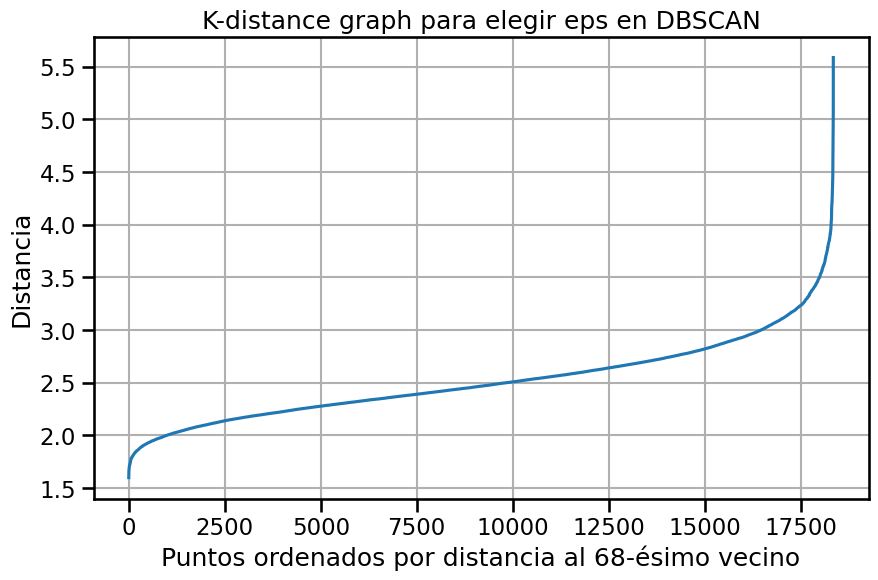

In [53]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples_val = 2 * df_scaled.shape[1]

neigh = NearestNeighbors(n_neighbors=min_samples_val)
nbrs = neigh.fit(df_scaled)
distances, indices = nbrs.kneighbors(df_scaled)

distances = np.sort(distances[:, min_samples_val - 1], axis=0)
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel(f"Puntos ordenados por distancia al {min_samples_val}-ésimo vecino")
plt.ylabel("Distancia")
plt.title("K-distance graph para elegir eps en DBSCAN")
plt.grid(True)
plt.show()

In [72]:
resultados_eps = []

for eps_val in [2.5, 3, 3.5, 4, 4.5]:
    db_tmp = DBSCAN(eps=eps_val, min_samples=min_samples_val).fit(df_scaled)
    labels_tmp = db_tmp.labels_

    n_clusters_tmp = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise_tmp = list(labels_tmp).count(-1)

    resultados_eps.append({
        'eps': eps_val,
        'n_clusters': n_clusters_tmp,
        'n_noise': n_noise_tmp,
        'tamaños': pd.Series(labels_tmp).value_counts().sort_index().to_dict()
    })

pd.DataFrame(resultados_eps)

,eps,n_clusters,n_noise,tamaños
0,2.5,2,1259,"{-1: 1259, 0: 15195, 1: 1896}"
1,3.0,2,112,"{-1: 112, 0: 16205, 1: 2033}"
2,3.5,2,11,"{-1: 11, 0: 2043, 1: 16296}"
3,4.0,2,2,"{-1: 2, 0: 16304, 1: 2044}"
4,4.5,2,1,"{-1: 1, 0: 16305, 1: 2044}"


Con eps=2.5, DBSCAN es "exigente": 1259 jugadores no encajan bien en ninguna de las dos masas densas → esto captura un conjunto de outliers mucho más amplio, probablemente jugadores con perfiles intermedios o atípicos en varias dimensiones.

Con eps=4.5, DBSCAN es tan permisivo que casi todo el mundo queda dentro de alguno de los 2 clusters, y solo 1 jugador (el caso más extremo posible) queda afuera.

In [54]:
eps_chosen = 3.5

db = DBSCAN(eps=eps_chosen, min_samples=min_samples_val).fit(df_scaled)
df_clusters['dbscan_cluster'] = db.labels_

n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f"DBSCAN encontró {n_clusters_db} clusters, {n_noise} puntos de ruido")
df_clusters['dbscan_cluster'].value_counts()

DBSCAN encontró 2 clusters, 11 puntos de ruido


,count
dbscan_cluster,
1,16296
0,2043
-1,11


In [55]:
# Jugadores identificados como ruido por DBSCAN (label == -1)
outliers_dbscan = df_clusters[df_clusters['dbscan_cluster'] == -1]

print(f"Cantidad de outliers: {len(outliers_dbscan)}")
outliers_dbscan[['short_name', 'principal_position', 'position', 'overall'] + skills]

Cantidad de outliers: 11


,short_name,principal_position,position,overall,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_handling,goalkeeping_diving,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
1147,V. Milinković-Savić,GK,GK,76,18,20,12,31,16,15,55,59,30,18,41,45,38,63,38,62,66,33,73,45,34,21,12,58,24,65.0,11,15,19,75,78,82,75,76
1554,Jean,GK,GK,75,13,10,13,27,6,13,62,64,29,22,28,31,41,61,67,51,59,20,65,10,18,14,7,44,66,28.0,14,11,11,75,74,68,76,78
2572,M. Fellaini,CM,Midfielder,73,58,71,92,77,69,66,64,46,69,79,34,34,34,68,83,76,85,76,90,64,87,70,83,71,65,75.0,67,71,70,6,8,9,15,16
3946,G. Castro,LM,Midfielder,71,78,71,66,82,82,75,78,75,77,81,51,58,44,53,84,76,72,30,79,75,38,43,68,77,71,81.0,35,62,37,16,9,15,10,14
4792,R. Santa Cruz,ST,Forward,70,58,78,78,63,77,63,73,52,45,75,31,35,30,61,28,76,67,30,80,60,66,35,77,63,75,76.0,35,25,31,6,13,8,6,8
5680,S. Mosquera,CB,Defender,69,23,40,79,53,22,45,45,75,49,56,54,53,52,56,35,75,87,50,90,68,65,63,23,26,62,63.0,73,69,65,9,13,8,9,7
8184,Kauã Zanson,CB,Defender,67,57,40,67,43,44,64,72,62,30,56,62,68,57,71,70,50,69,38,63,50,73,69,42,56,46,72.0,70,70,72,9,8,11,8,10
9106,Víctor Vázquez,CAM,Midfielder,66,71,62,49,76,69,68,78,73,73,73,30,30,34,64,71,62,47,31,60,69,49,49,64,72,71,73.0,45,45,24,16,8,8,15,8
9221,A. Ateef,CDM,Midfielder,66,70,41,47,73,34,60,65,53,78,69,27,28,61,65,52,49,48,29,50,47,47,69,65,75,60,74.0,69,65,60,12,11,6,7,11
9344,Estevãtinho,CAM,Midfielder,66,74,54,49,73,49,63,63,68,72,71,42,45,58,52,70,49,52,49,66,73,44,23,64,78,44,62.0,12,33,35,9,10,12,8,12


In [56]:
outliers_dbscan[['short_name', 'principal_position', 'position', 'overall', 'club_name']]

,short_name,principal_position,position,overall,club_name
1147,V. Milinković-Savić,GK,GK,76,Torino
1554,Jean,GK,GK,75,Cerro Porteño
2572,M. Fellaini,CM,Midfielder,73,Shandong Taishan
3946,G. Castro,LM,Midfielder,71,Nacional
4792,R. Santa Cruz,ST,Forward,70,Libertad
5680,S. Mosquera,CB,Defender,69,Atlético Nacional
8184,Kauã Zanson,CB,Defender,67,Fluminense
9106,Víctor Vázquez,CAM,Midfielder,66,Toronto
9221,A. Ateef,CDM,Midfielder,66,Al Ahli Jeddah
9344,Estevãtinho,CAM,Midfielder,66,Fluminense


In [57]:
comparacion = pd.DataFrame({
    'outliers_dbscan': outliers_dbscan[skills].mean(),
    'promedio_general': df_skills[skills].mean()
})
comparacion['diferencia'] = comparacion['outliers_dbscan'] - comparacion['promedio_general']
comparacion.sort_values('diferencia', key=abs, ascending=False)

,outliers_dbscan,promedio_general,diferencia
movement_acceleration,39.363636,64.583052,-25.219415
movement_sprint_speed,41.545455,64.753406,-23.207951
power_stamina,40.727273,62.863869,-22.136596
skill_fk_accuracy,64.000000,42.736240,21.263760
skill_curve,66.000000,47.750518,18.249482
movement_agility,46.727273,63.414332,-16.687060
mentality_penalties,59.636364,47.795804,11.840560
power_long_shots,56.636364,46.634060,10.002304
mentality_composure,67.636364,57.976240,9.660124
mentality_vision,62.727273,54.246649,8.480624


Las 3 diferencias más grandes son físicas, y las 3 están en la misma dirección: muy por debajo del promedio.

Y las diferencias positivas más grandes son técnicas.

Este grupo de outliers son jugadores con un perfil atípico dentro del dataset — muy lentos/poco físicos mezclado con técnica alta. El algoritmo los aísla porque ningún cluster "normal" combina baja velocidad con alta técnica de esa forma

4.5 Clustering jerárquico (dendrograma, Ward)

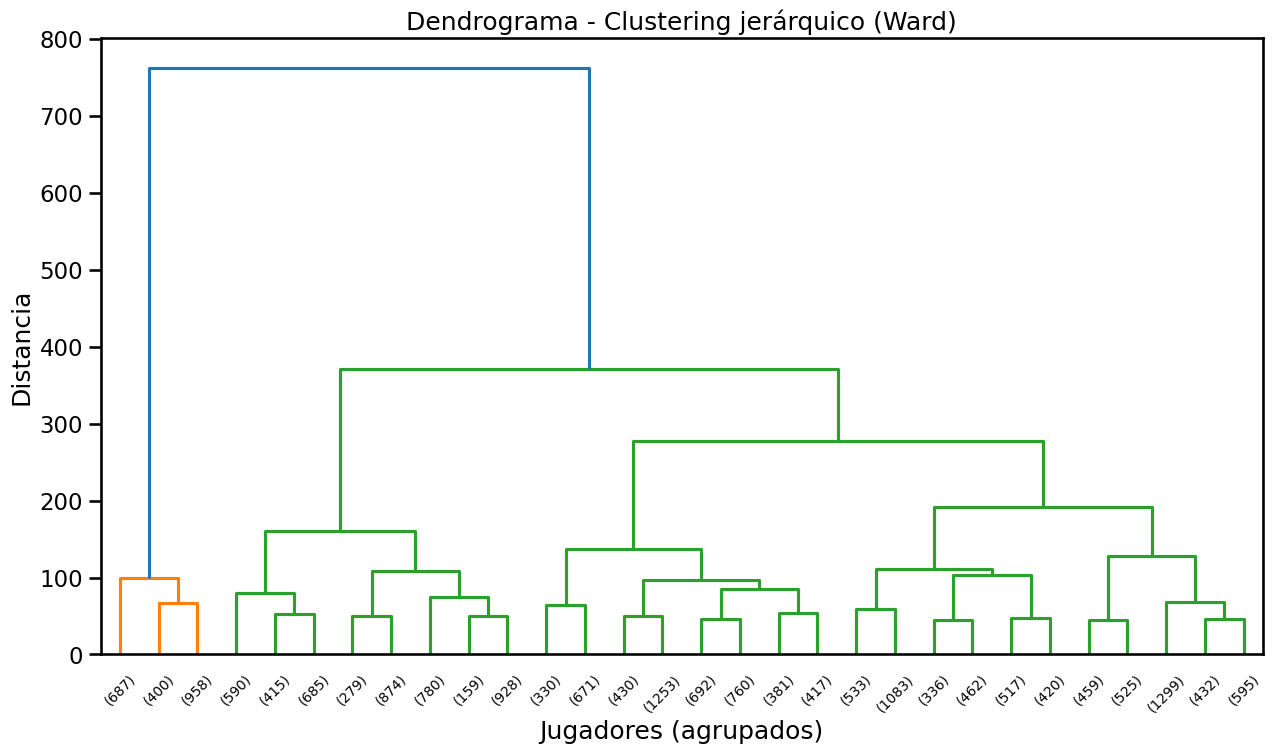

In [58]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

dm = linkage(df_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(dm, truncate_mode='lastp', p=30)
plt.title('Dendrograma - Clustering jerárquico (Ward)')
plt.xlabel('Jugadores (agrupados)')
plt.ylabel('Distancia')
plt.show()

In [59]:
n_clust = 4
df_clusters['hier_cluster'] = fcluster(dm, n_clust, criterion='maxclust')
df_clusters['hier_cluster'].value_counts()

,count
hier_cluster,
4,6661
3,4934
2,4710
1,2045


## **5. Análisis cualitativo de los clusters encontrados.**

In [60]:
# Tabla de contingencia cluster vs posición
pd.crosstab(index=df_clusters['kmeans_cluster'], columns=df_clusters['position'])

position,Defender,Forward,GK,Midfielder
kmeans_cluster,,,,
0,135,2671,0,2263
1,0,0,2045,0
2,1603,772,0,3462
3,4436,15,0,948


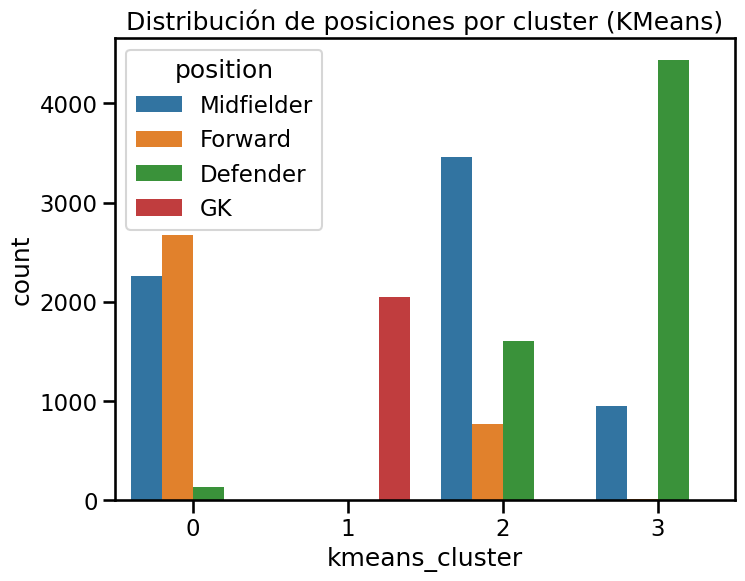

In [61]:
plt.figure(figsize=(8,6))
sns.countplot(data=df_clusters, x='kmeans_cluster', hue='position')
plt.title('Distribución de posiciones por cluster (KMeans)')
plt.show()

eE clustering separa razonablemente bien arqueros y defensores, pero no logra separar limpiamente Forward de Midfielder; tiene sentido porque comparten muchas habilidades técnicas.

In [62]:
# 5 jugadores representativos de cada cluster
for cluster in sorted(df_clusters['kmeans_cluster'].unique()):
    print(cluster, df_clusters[df_clusters['kmeans_cluster']==cluster]['short_name'].values[:5])

0 ['Brahim' 'F. Balogun' 'Evanilson' 'H. Diallo' 'Albertinho Dutra']
1 ['T. Courtois' 'Alisson' 'M. ter Stegen' 'Ederson' 'J. Oblak']
2 ['K. Mbappé' 'E. Haaland' 'K. De Bruyne' 'L. Messi' 'K. Benzema']
3 ['Gabriel' 'Kim Min Jae' 'C. Smalling' 'M. Škriniar' 'S. Botman']


In [63]:
# Estadística descriptiva de skills por cluster
df_clusters.groupby('kmeans_cluster')[skills].mean().T

kmeans_cluster,0,1,2,3
attacking_crossing,51.482146,13.663081,63.687168,45.166327
attacking_finishing,60.273821,10.439120,58.922392,33.096685
attacking_heading_accuracy,51.937660,13.726650,58.582320,58.740508
attacking_short_passing,59.398895,27.977506,70.504883,58.141508
attacking_volleys,52.436575,10.684597,54.492890,32.037414
skill_dribbling,63.909844,12.910513,69.163611,50.499167
skill_curve,52.519037,14.232763,63.119411,39.353399
skill_fk_accuracy,46.869402,13.546699,57.081035,34.403408
skill_long_passing,50.675281,27.422494,66.361487,52.598259
skill_ball_control,63.571119,19.284108,70.689909,55.864049


In [64]:
promedio_general = df_skills[skills].mean()

for cluster in sorted(df_clusters['kmeans_cluster'].unique()):
    medias_cluster = df_clusters[df_clusters['kmeans_cluster'] == cluster][skills].mean()
    diferencia = (medias_cluster - promedio_general).sort_values(key=abs, ascending=False)

    print(f"--- Cluster {cluster} (n={sum(df_clusters['kmeans_cluster']==cluster)}) ---")
    print(diferencia.head(4))
    print()

--- Cluster 0 (n=5069) ---
mentality_interceptions       -17.226785
defending_standing_tackle     -16.494854
defending_sliding_tackle      -16.227540
defending_marking_awareness   -15.511718
dtype: float64

--- Cluster 1 (n=2045) ---
goalkeeping_reflexes       49.291100
goalkeeping_diving         48.475517
goalkeeping_positioning    46.974395
goalkeeping_handling       46.704273
dtype: float64

--- Cluster 2 (n=5837) ---
power_long_shots      15.765632
skill_curve           15.368893
attacking_crossing    14.395669
skill_fk_accuracy     14.344795
dtype: float64

--- Cluster 3 (n=5399) ---
defending_sliding_tackle       15.231458
defending_standing_tackle      15.048314
defending_marking_awareness    14.303204
mentality_interceptions        14.163091
dtype: float64



Cluster 0  — Perfil ofensivo/técnico.

Cluster 1  — Arqueros

Cluster 2  — Perfil técnico-ofensivo de pase largo

Cluster 3  — Perfil defensivo

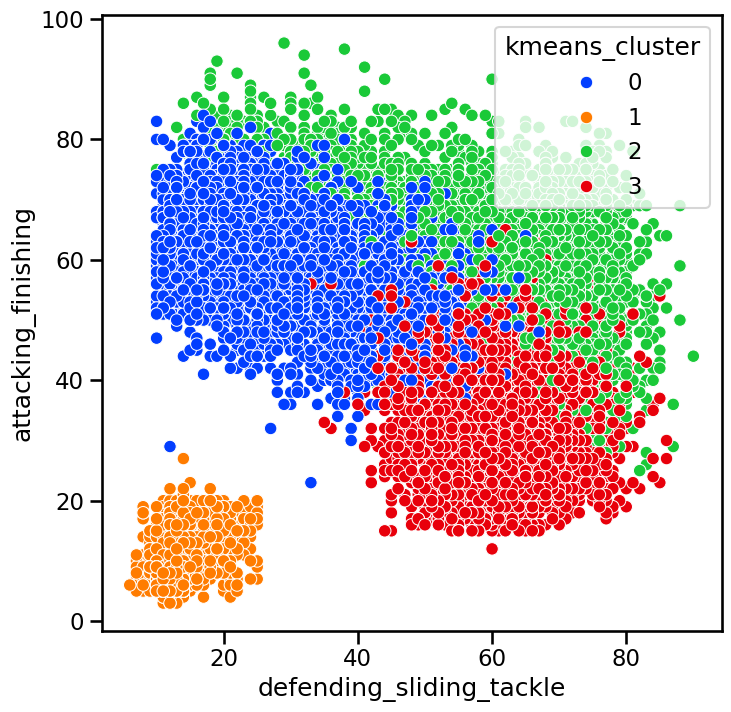

In [65]:
plt.figure(figsize=(8,8))
sns.scatterplot(x='defending_sliding_tackle', y='attacking_finishing', hue='kmeans_cluster', data=df_clusters, palette='bright')

plt.show()

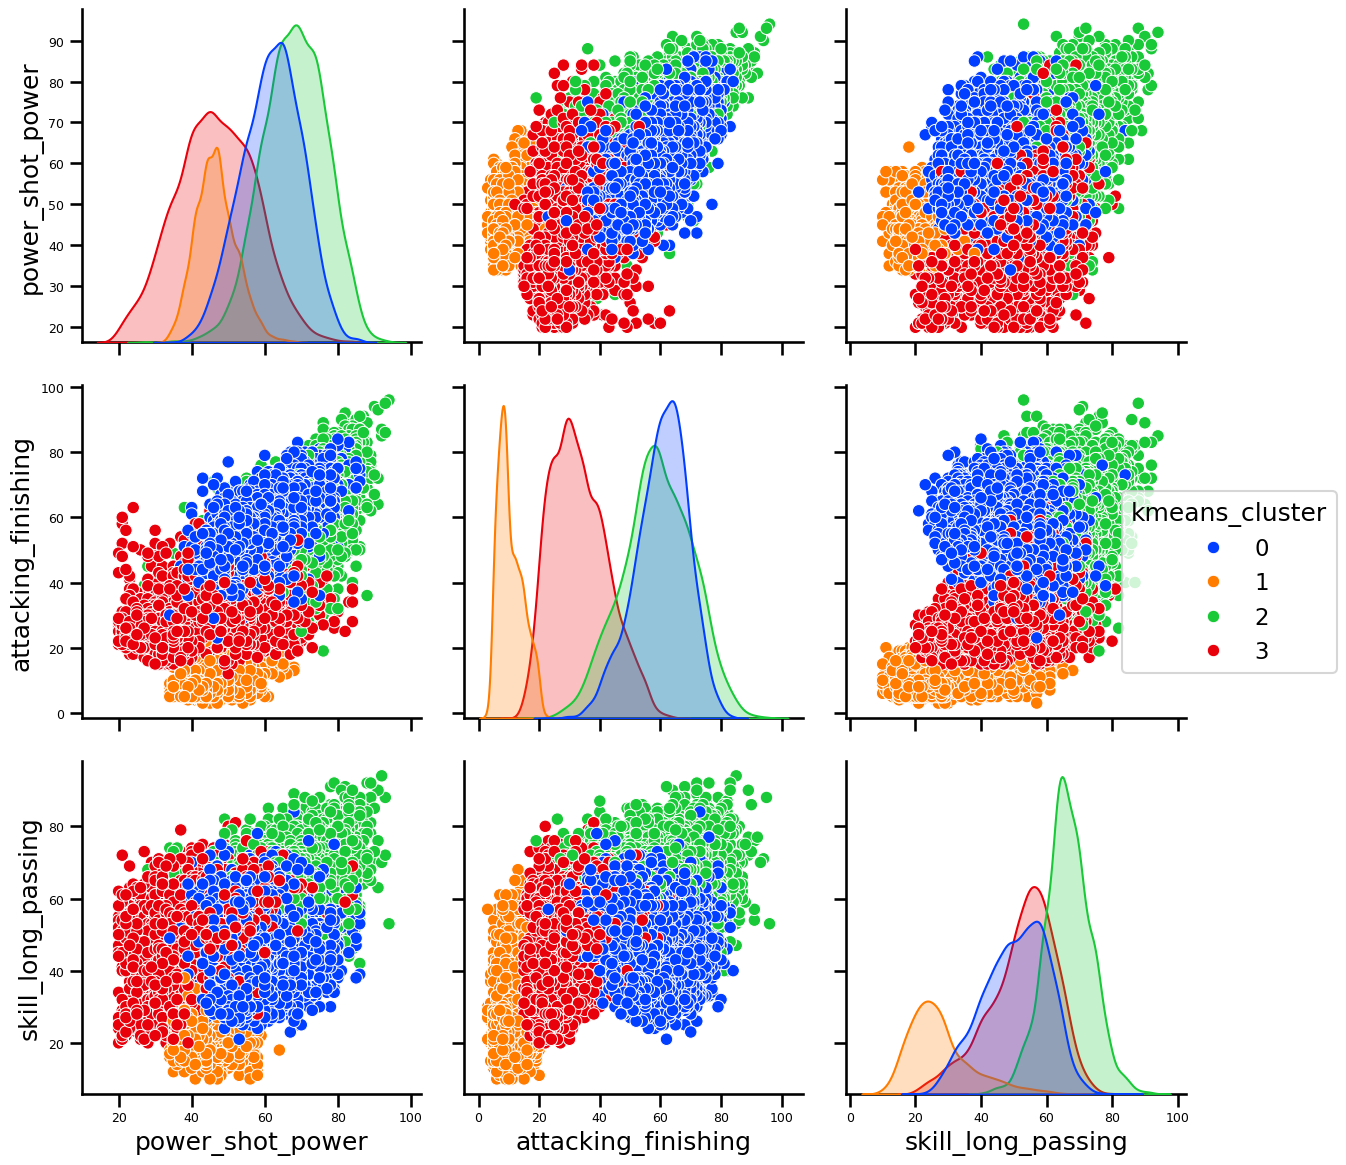

In [66]:
data_temp = df_clusters[['kmeans_cluster', 'power_shot_power', 'attacking_finishing', 'skill_long_passing']]

g = sns.pairplot(data_temp, hue='kmeans_cluster', palette='bright', height=3.5)
g.fig.set_size_inches(13, 12)

# Sacar la leyenda automática y crear una nueva, afuera de los subplots
g._legend.remove()
handles = g._legend_data.values()
labels = g._legend_data.keys()
g.fig.legend(handles=handles, labels=labels, title='kmeans_cluster',
             loc='center right', bbox_to_anchor=(1.05, 0.5))

for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(axis='both', labelsize=9)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

El algoritmo separa con alta claridad a los arqueros (Cluster 1) y logra una separación razonable entre perfiles ofensivos (Cluster 0) y defensivos (Cluster 3) usando variables tácticamente opuestas. El Cluster 2, sin embargo, se superpone con ambos extremos en las variables de finishing/tackle, y solo se distingue claramente en pase largo y tiro de media/larga distancia — evidenciando que agrupa un perfil de jugador técnicamente completo más que una posición táctica específica

## **6. Visualización de resultados (proyección, Embedding)**.

Uso de alguna transformación (proyección, Embedding) para visualizar los resultados y/o usarla como preprocesado para aplicar alguna técnica de clustering.

In [67]:
from sklearn.decomposition import PCA

pca = PCA()
pca_fit = pca.fit_transform(df_scaled)

explained_variance = pca.explained_variance_ratio_
cum_var_exp = np.cumsum(explained_variance)

for i, (var, cum) in enumerate(zip(explained_variance, cum_var_exp)):
    print(f"{i+1}\t{cum:.4f}\t{var:.4f}")

1	0.5776	0.5776
2	0.7190	0.1415
3	0.8022	0.0831
4	0.8567	0.0545
5	0.8900	0.0333
6	0.9028	0.0128
7	0.9129	0.0101
8	0.9218	0.0089
9	0.9298	0.0080
10	0.9372	0.0074
11	0.9438	0.0066
12	0.9498	0.0059
13	0.9551	0.0053
14	0.9604	0.0053
15	0.9651	0.0047
16	0.9693	0.0042
17	0.9734	0.0040
18	0.9769	0.0035
19	0.9800	0.0032
20	0.9825	0.0025
21	0.9847	0.0022
22	0.9868	0.0021
23	0.9886	0.0018
24	0.9904	0.0017
25	0.9918	0.0015
26	0.9933	0.0014
27	0.9946	0.0013
28	0.9955	0.0009
29	0.9964	0.0009
30	0.9973	0.0008
31	0.9981	0.0008
32	0.9988	0.0008
33	0.9994	0.0006
34	1.0000	0.0006


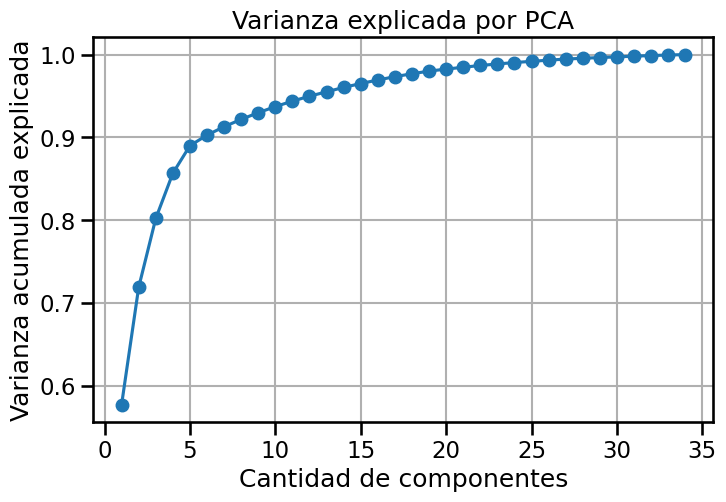

In [68]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var_exp)+1), cum_var_exp, marker='o')
plt.xlabel('Cantidad de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('Varianza explicada por PCA')
plt.grid(True)
plt.show()

Con 2 componentes explicmos el 71.9% de la varianza

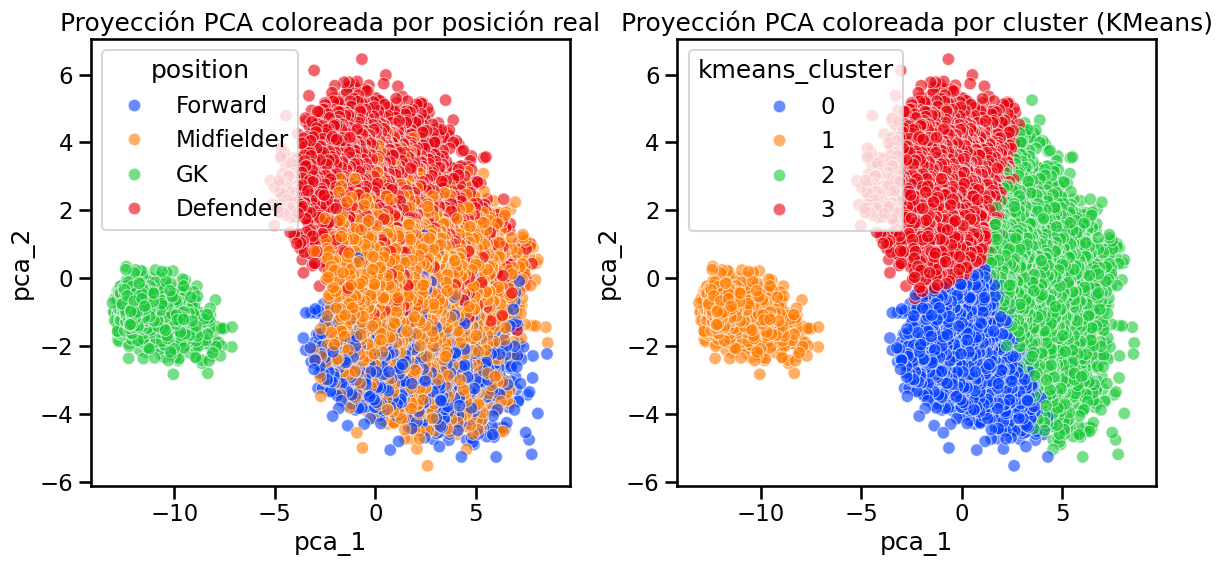

In [69]:
df_clusters['pca_1'] = pca_fit[:, 0]
df_clusters['pca_2'] = pca_fit[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12,6))

sns.scatterplot(x='pca_1', y='pca_2', hue='position', data=df_clusters, palette='bright', ax=axes[0], alpha=0.6)
axes[0].set_title('Proyección PCA coloreada por posición real')

sns.scatterplot(x='pca_1', y='pca_2', hue='kmeans_cluster', data=df_clusters, palette='bright', ax=axes[1], alpha=0.6)
axes[1].set_title('Proyección PCA coloreada por cluster (KMeans)')

plt.tight_layout()
plt.show()

El cluster naranja (arqueros) se separa perfectamente del resto tanto en la proyección real como en la de KMeans, y la frontera entre Forward/Midfielder/Defender que dibuja KMeans es razonablemente parecida a la frontera real, aunque no idéntica.

Métricas comparativas entre métodos (como en clustering_3)

In [70]:
from sklearn import metrics

clustering_metrics = [
    metrics.homogeneity_score,
    metrics.completeness_score,
    metrics.v_measure_score,
    metrics.adjusted_rand_score,
    metrics.adjusted_mutual_info_score,
]

metodos = {
    'KMeans': df_clusters['kmeans_cluster'],
    'MeanShift': df_clusters['meanshift_cluster'],
    'DBSCAN': df_clusters['dbscan_cluster'],
    'Jerárquico (Ward)': df_clusters['hier_cluster'],
}

resultados = {}
for nombre, labels in metodos.items():
    resultados[nombre] = [m(df_clusters['position'], labels) for m in clustering_metrics]

pd.DataFrame(resultados, index=['Homogeneidad','Completitud','V-measure','ARI','AMI']).T

,Homogeneidad,Completitud,V-measure,ARI,AMI
KMeans,0.491168,0.479735,0.485384,0.362313,0.485288
MeanShift,0.107411,0.166571,0.130604,0.045679,0.130470
DBSCAN,0.270070,0.985978,0.424001,0.185788,0.423879
Jerárquico (Ward),0.444887,0.437704,0.441266,0.312136,0.441161


- KMeans es el que mejor equilibra homogeneidad y completitud (V-measure y ARI más altos).
- MeanShift y DBSCAN tienen completitud altísima pero homogeneidad baja — esto es porque ambos colapsaron casi todo en un cluster gigante, al haber pocos clusters muy grandes, es fácil que cada posición real quede casi completa dentro de un solo cluster, pero ese cluster mezcla varias posiciones.
- Jerárquico queda en un punto intermedio, algo peor que KMeans.

## **7. Comparación de interpretaciones humano vs. LLMs sobre el análisis de clusters.**

Para reflexionar críticamente sobre el rol del conocimiento experto/de dominio frente a la interpretación automática de resultados de clustering, y sobre las capacidades y limitaciones actuales de los modelos de lenguaje para el análisis de datos.

a) Tomar los resultados del punto 5 (caracterización de clusters ya realizada por el grupo) y presentarle a Claude, ChatGPT y Gemini exactamente la misma información: por ejemplo, tabla de centroides/estadísticos descriptivos por cluster, tamaño de cada cluster, y las variables utilizadas para clusterizar (sin incluir la interpretación propia del grupo, para no sesgar al modelo).

b) Pedirle a cada uno de los tres modelos, con el mismo prompt, que interprete los clusters: qué representa cada uno, si los jugadores dentro de un cluster son "equivalentes", y qué podría explicar la heterogeneidad o el tamaño de los grupos.

c) Documentar textualmente (o via capturas) las tres respuestas obtenidas.

d) Realizar un análisis comparativo entre las tres respuestas y la interpretación propia del grupo (la del punto 5), atendiendo especialmente a:

- Coincidencias y diferencias entre los tres modelos.

- Casos en que algún modelo haya "alucinado" datos, sacado conclusiones no sustentadas por los números, o generalizado de forma poco rigurosa.

- Casos en que el grupo, gracias a conocimiento de dominio (reglas del fútbol, entendimiento de posiciones, lógica de mercado de pases, conocimiento de jugadores reales, contexto de la temporada/base de datos, etc.), pudo identificar matices, errores o explicaciones que ningún modelo mencionó.

- Información contextual que un experto humano valora naturalmente pero que los modelos no tienen forma de inferir sólo de números (ej.: un jugador lesionado en el momento del snapshot de datos, un jugador joven con potencial subestimado por las métricas actuales, diferencias entre ligas de distinto nivel competitivo que igualan estadísticas de forma engañosa, etc.).

- Diferencias en el "tono" de certeza: ¿los modelos matizan sus afirmaciones o presentan interpretaciones especulativas como si fueran hechos?

e) Conclusión breve reflexionando sobre: ¿en qué tareas de este análisis un LLM aporta valor real (por ejemplo, generación rápida de hipótesis, redacción, resumen)? ¿En qué tareas resulta insuficiente o directamente engañoso sin supervisión experta? ¿Qué rol debería tener, en la práctica profesional de un/a científico/a de datos, el uso de estas herramientas para interpretar resultados de un análisis no supervisado?